In [2]:
#!pip install "PolyBin3D @ git+https://github.com/oliverphilcox/PolyBin3D"
#!pip install git+https://github.com/cosmodesi/pypower
#!mkdir precomps

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from funcs import get_delta, compute_Pk, compute_Bk,calculate_acc_from_phi_k, correct_pos, compute_XPk, get_roots,MAS_correction, terms_root, get_roots_gamma, terms_root_gamma, get_roots_overdensity
import scipy
import h5py, itertools
from scipy.fft import *

import progressbar
import inspect
import os
from sys import getsizeof

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from mpl_toolkits.axes_grid1 import make_axes_locatable

import matplotlib.colors as colors
import colorsys
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib.patches import Circle, Rectangle
from matplotlib.patheffects import withStroke
from matplotlib.ticker import FormatStrFormatter, ScalarFormatter
import matplotlib.ticker as mtick

# Pylians
import readgadget
import MAS_library as MASL
import Pk_library as PKL
import plotting_library as PL
import smoothing_library as SL
from Pk_library import MAS_correction as MAS_corr_pylians
#from nbodykit.lab import *

# pypower
from pypower import CatalogMesh, MeshFFTPower, CatalogFFTPower, PowerSpectrumStatistics, utils, setup_logging

# Scipy
from scipy.interpolate import interp1d

#Polybin3D
import PolyBin3D as pb

# Emulators
import symbolic_pofk.syrenhalofit as syrenhalofit
import symbolic_pofk.linear as linear
import astropy.cosmology as cosmo

# Conveniences
format_float = lambda z: "%ip%i"%(int(z // 1), int(z%1 *10))

def sci_notation(number, sig_fig=2):
    ret_string = "{0:.{1:d}e}".format(number, sig_fig)
    a, b = ret_string.split("e")
    # remove leading "+" and strip leading zeros
    b = int(b)
    return a + r"$\times 10^{%i}$"%b

plt.style.use("dark_background")

import time
print("Numpy Version: ", np.__version__)
# For opti tests
import pyfftw
from numba import njit, jit, prange

import psutil
from psutil._common import bytes2human
print("total memory:" ,bytes2human(psutil.virtual_memory()[0]))
print('memory % used:', psutil.virtual_memory()[2])
print("number of cpus :", os.cpu_count())

--------------------------------------------------------------------------

  Local host:   a030
  Local device: mlx5_0
--------------------------------------------------------------------------
[a030.anvil.rcac.purdue.edu:1303640] common_ucx.c:362  Warning: UCX is unable to handle VM_UNMAP event. This may cause performance degradation or data corruption. Pls try adding --mca opal_common_ucx_opal_mem_hooks 1 to mpirun/oshrun command line to resolve this issue.


Numpy Version:  1.23.5
total memory: 251.5G
memory % used: 12.7
number of cpus : 128


# 0) Very brief summary
**A handful of equation for different test cases**

The goal is to perturbed particles positions 

\begin{align}
\mathbf{x}_i' = \mathbf{x}_i + \nabla\phi(\mathbf{x}_i)
\end{align}

## Main equations

We use the convention that $\Delta$ designates the fractional overdensity field, meaning in comoving space

$\Delta(\mathbf{x}) = \frac{\rho(\mathbf{x}) - \rho_\text{mean}}{\rho_\text{mean}}$
with $\rho(\mathbf{x}) = \sum_{i=1}^n \delta(\mathbf{x} - \mathbf{x}_i)$ defined with the Delta function.

The main equation for the Fourier transform of the density field of the perturbed tracer $\Delta_k^{'}$ is

\begin{align}
|\Delta^{'}_\mathbf{k}|^2 &= \Delta^{'}_\mathbf{k}\Delta^{' \ast}_\mathbf{k}  \\
&= \left[ \Delta_\mathbf{k} + k^2\phi_{\mathbf{k}} +
\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}} 
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}  
\right) \right] \times \nonumber\\
&\left[\Delta^{\ast}_\mathbf{k} + k^2\phi_{\mathbf{k}}^{\ast} +
\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber\\
|\Delta^{'}_\mathbf{k}|^2 &\approx_{\mathcal{O}(\phi^2)} |\Delta_{\mathbf{k}}|^2 + k^4 |\phi_{\mathbf{k}}|^2 + \frac{1}{V^2} \sum_{\mathbf{q},\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \phi_{\mathbf{q}}
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast} \nonumber\\
 &+ 2 \operatorname{Re}\left[ k^2\Delta_{\mathbf{k}}\phi_{\mathbf{k}}^{\ast} +\frac{k^2}{V} \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{k}}\phi_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast} \right. \nonumber \\
 &+\left. \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \phi_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}
\left(\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}
    +\frac{1}{2}\mathbf{k} \cdot (\mathbf{k-q})\phi_{\mathbf{k-q}}^{\ast}
    +\frac{1}{2V}
\sum_{\mathbf{q'}} (\mathbf{k} \cdot \mathbf{q'})
 \phi_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast} 
\right) \right] \nonumber 
\end{align}



**MAS kernel reminder**

In the review by [Angulo & Hahn](https://arxiv.org/abs/2112.05165), equation 62 reminds the formulae for the MAS kernel Fourier transform (p=1 for NGP and 2 for CiC)

\begin{equation}
W(k) = \left[ \mathrm{sin}_c(\frac{\pi k}{2 k_N}) \right]^p
\end{equation}

where the Nyquist wavenumber is $k_N = \frac{\pi N}{L} = \frac{1}{2}\frac{2\pi}{\Delta_x}$.

**17th of December 2025**
- without the quad. term in gamma, with the bispectrum, we can turn the system as a linear matrix form inversion (integral as sum)
- for the uncorrelated case below, same idea for the linear inversion with sums instead of numerical integrals.
- if in the end root finding is required, turn to Jax with custom gradients (homework: to derive)
- weekly reminder: interlacing estimators exist :) 

**21rst of January 2026**
- clean the correlated case with pypower, make term contributions plot
- do the bispectrum system with the pypower Pks, with and without the gamma quadratic term
- uncorrelated case: restart with pypower
- make the plot gamma_k instead of gamma_k over k^2 (just after finding the roots)

## Functions and numba implementation for displacements

In [2]:
#####################################################################
# NN = Nearest Neighbor interpolations, older functions for reference
#####################################################################
@njit
def gradient_nn(positions, grad_nnx, grad_nny, grad_nnz, grad_x, grad_y, grad_z, array_length, max_length):
    '''
    Nearest neighbor computation
    '''
    N = positions.shape[0]
    for n in prange(N):

        # Calculate at nearest voxel
        x_index = np.argmin((positions[n,0] - array_length)**2)
        y_index = np.argmin((positions[n,1] - array_length)**2)
        z_index = np.argmin((positions[n,2] - array_length)**2)

        grad_nnx[n] = grad_x[x_index,y_index,z_index]
        grad_nny[n] = grad_y[x_index,y_index,z_index]
        grad_nnz[n] = grad_z[x_index,y_index,z_index]
        
    return grad_nnx, grad_nny, grad_nnz

@njit
def displace_positions_nn(positions, new_positions, grad_x, grad_y, grad_z, array_length, max_length):
    '''
    Nearest neighbor computation
    '''
    N = positions.shape[0]
    for n in prange(N):

        # Calculate at nearest voxel
        x_index = np.argmin((positions[n,0] - array_length)**2)
        y_index = np.argmin((positions[n,1] - array_length)**2)
        z_index = np.argmin((positions[n,2] - array_length)**2)

        new_positions[n,0] = np.mod(positions[n,0] + grad_x[x_index,y_index,z_index], max_length)
        new_positions[n,1] = np.mod(positions[n,1] + grad_y[x_index,y_index,z_index], max_length)
        new_positions[n,2] = np.mod(positions[n,2] + grad_z[x_index,y_index,z_index], max_length)
        
    return new_positions

##############################################################
# Trilinear interpolation with periodic bounds, default scheme
##############################################################
@njit
def trilinear_interp_numba(data, points, x_coords, y_coords, z_coords):
    """
    Trilinear interpolation on a REGULAR 3D array using Numba.
    For irregular 3D grids, we could do some slight modifications

    Args:
        data (np.ndarray): The 3D array containing the data to interpolate.
        points (np.ndarray): A 2D array where each row represents query coordinates (x, y, z).
        x_coords (np.ndarray): 1D array of x-coordinates for the data grid.
        y_coords (np.ndarray): 1D array of y-coordinates for the data grid.
        z_coords (np.ndarray): 1D array of z-coordinates for the data grid.

    Returns:
        np.ndarray: An array of interpolated values corresponding to the query points.
    """
    nx, ny, nz = data.shape
    num_points = points.shape[0]
    interpolated_values = np.empty(num_points, dtype=data.dtype)

    # ASSUMING REGULAR GRIDS: Pre-calculate inverse outside the loop
    dx_inv = 1.0 / (x_coords[1] - x_coords[0])
    dy_inv = 1.0 / (y_coords[1] - y_coords[0])
    dz_inv = 1.0 / (z_coords[1] - z_coords[0]) 

    print(dx_inv, dy_inv, dz_inv)

    for i in prange(num_points):
        
        x_query, y_query, z_query = points[i,:]

        # Indices of cube around query point
        x0_idx = np.searchsorted(x_coords, x_query, side = "left")-1
        y0_idx = np.searchsorted(y_coords, y_query, side = "left")-1
        z0_idx = np.searchsorted(z_coords, z_query, side = "left")-1

        # Ensure bounds are correct
        #x0_idx = max(0, min(x0_idx, nx - 2))
        #y0_idx = max(0, min(y0_idx, ny - 2))
        #z0_idx = max(0, min(z0_idx, nz - 2))
        x0_idx = x0_idx%nx
        y0_idx = y0_idx%ny
        z0_idx = z0_idx%nz
        x1_idx = (x0_idx + 1)%nx # not needed because regular grid ! -> Actually we need for periodic conditions
        y1_idx = (y0_idx + 1)%ny
        z1_idx = (z0_idx + 1)%ny

        x0 = x_coords[x0_idx]
        y0 = y_coords[y0_idx]
        z0 = z_coords[z0_idx]

        # Linear interpolation weights
        xd = (x_query - x0) * dx_inv
        yd = (y_query - y0) * dy_inv
        zd = (z_query - z0) * dz_inv

        # Perform trilinear interpolation (hard-coded formula for 8 corners)
        c000 = data[x0_idx, y0_idx, z0_idx]
        c100 = data[x1_idx, y0_idx, z0_idx]
        c010 = data[x0_idx, y1_idx, z0_idx]
        c001 = data[x0_idx, y0_idx, z1_idx]
        c110 = data[x1_idx, y1_idx , z0_idx]
        c101 = data[x1_idx, y0_idx, z1_idx]
        c011 = data[x0_idx, y1_idx, z1_idx]
        c111 = data[x1_idx, y1_idx, z1_idx]

        interpolated_value = (
            c000 * (1 - xd) * (1 - yd) * (1 - zd) +
            c100 * xd * (1 - yd) * (1 - zd) +
            c010 * (1 - xd) * yd * (1 - zd) +
            c001 * (1 - xd) * (1 - yd) * zd +
            c110 * xd * yd * (1 - zd) +
            c101 * xd * (1 - yd) * zd +
            c011 * (1 - xd) * yd * zd +
            c111 * xd * yd * zd
        )
        interpolated_values[i] = interpolated_value

    return interpolated_values

@njit
def displace_positions_interp(positions, new_positions, grad_x, grad_y, grad_z, x_c, y_c, z_c, max_length, threshold = None):
    '''
    3D interpolation in numba computation
    '''
    nabla_x = trilinear_interp_numba(grad_x, positions, x_c, y_c, z_c) #"c" for comoving coordinates
    nabla_y = trilinear_interp_numba(grad_y, positions, x_c, y_c, z_c)
    nabla_z = trilinear_interp_numba(grad_z, positions, x_c, y_c, z_c)

    if threshold is not None:
        nabla_x[np.abs(nabla_x)>threshold]=0
        nabla_y[np.abs(nabla_y)>threshold]=0
        nabla_z[np.abs(nabla_z)>threshold]=0

    # Also make periodic boundary conditions
    new_positions[:,0] = np.mod(positions[:,0] + nabla_x , max_length)
    new_positions[:,1] = np.mod(positions[:,1] + nabla_y , max_length)
    new_positions[:,2] = np.mod(positions[:,2] + nabla_z , max_length)
            
    return new_positions, nabla_x, nabla_y, nabla_z

##############################################
# Fourier operations for the 3D (regular) grid
##############################################

# @jit(nopython=True) has for alias @njit
@njit
def fill_fourier_grid(weights_grid, k3D_radius , k_bins, weights1D):
    '''
    interpolate the gamma_k/k**2=weights1D to multiplty the three-dimensional Phi_k with
    '''
    for ix in prange(k3D_radius.shape[0]):
        for iy in prange(k3D_radius.shape[1]):
            for iz in prange(k3D_radius.shape[2]):
                weights_grid[ix,iy,iz] = np.interp(k3D_radius[ix,iy,iz], k_bins, weights1D) #(x,xp,fp)
    return weights_grid

def fourier_shells_k(res, box_size, fshift = True):
    '''
    Use fhsift=True to move the zero frequency component at the center of arrays
    '''
    scale = 2*np.pi*res/box_size # k resolution
    if fshift:
        k_x = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_y = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32')
        k_z = np.array(scale*np.fft.fftshift(np.fft.fftfreq(res)), dtype='float32') # not fftshift for redundant "refreq" case
    else:
        k_x = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_y = np.array(scale*np.fft.fftfreq(res), dtype='float32')
        k_z = np.array(scale*np.fft.fftfreq(res), dtype='float32')

    kx, ky, kz = np.meshgrid(k_x, k_y, k_z, indexing='ij')
    k_radius_grid = np.sqrt(kx**2 + ky**2 + kz**2)
        
    return k_x, k_y, k_z, k_radius_grid

# 1) Setup and load data
The Quijote fiducial simulations parameters are reminded in the [documentation](https://quijote-simulations.readthedocs.io/en/latest/types.html). 
We will try to perturb a L-PICOLA snapshot, with the reference being either the Quijote simulation at the same seed or from the [symbolik_pofk](https://github.com/DeaglanBartlett/symbolic_pofk) emulator.

In [3]:
params=["Omega_m", "Omega_b", "h", "n_s", "sigma_8"]
cosmology = {"sigma_8":0.834, "n_s":0.9624, "h":0.671, "Omega_b":0.049,
            "Omega_m":0.3175}

In [4]:
os.makedirs?

Signature: os.makedirs(name, mode=511, exist_ok=False)
Docstring:
makedirs(name [, mode=0o777][, exist_ok=False])

Super-mkdir; create a leaf directory and all intermediate ones.  Works like
mkdir, except that any intermediate path segment (not just the rightmost)
will be created if it does not exist. If the target directory already
exists, raise an OSError if exist_ok is False. Otherwise no exception is
raised.  This is recursive.
File:      ~/miniconda3/envs/pkcorr/lib/python3.10/os.py
Type:      function

In [5]:
# SETUP PARAMS
grid = 256
BoxSize=1000.0 # Mpc/h
#voxel_size = np.array(3*[BoxSize/grid])
MAS='CIC'
MAS_index=2

kNyquist = np.pi * grid/BoxSize

redshift = 0.5
a = 1 / (1+redshift)
z_str = format_float(redshift)
seed = 1

# SNAPSHOT LOCATIONS
nbody = "/anvil/scratch/x-nchartier/snapshots/quijote_fid_z%s_seed%i/snapdir_003/snap_003"%(z_str,seed)
nbodystr = "Quijote"

app = "/anvil/scratch/x-nchartier/snapshots/cola_fid_z%s_seed%i/Cola1_20steps_mesh512_nLPTpos0p5_z0p500"%(z_str,seed)
appstr = "LPICOLA"
ptype   = [1] #[1](CDM), [2](neutrinos) or [1,2](CDM+neutrinos)

basedir = "/home/x-nchartier/PkCorr/Figures"

if not os.path.exists(os.path.join(basedir, appstr)):
    os.makedirs(os.path.join(basedir, appstr), exist_ok=False)

# TODO: test on fastpm sims with saved DM particles
# fpm = "/anvil/scratch/x-mho1/cmass-ili/quijotelike/fastpm/L1000-N128/%i/"%seed
# file = h5py.File(os.path.join(fpm, "nbody.h5"))
# print(file.keys())
# data = file['0.666667']
# print(data.keys())
# file.close()

In [6]:
# read header for nbody
header   = readgadget.header(nbody)
BoxSize  = header.boxsize/1e3  #Mpc/h
print("BoxSize = %.1f Mpc"%BoxSize)
Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3)
Masses   = header.massarr*1e10 #Masses of the particles in Msun/h
Omega_m  = header.omega_m      #value of Omega_m
print(r"$\Omega_m = %.4f$"%Omega_m)
Omega_l  = header.omega_l      #value of Omega_l
print(r"$\Omega_{\Lambda} = %.4f$"%Omega_l)
h        = header.hubble       #value of h
print(r"$h=%.4f$"%h)
#redshift = header.redshift     #redshift of the snapshot
Hubble   = 100.0*np.sqrt(Omega_m*(1.0+redshift)**3+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble)
Hubble_0   = 100.0*np.sqrt(Omega_m+Omega_l)#Value of H(z) in km/s/(Mpc/h)
print(Hubble_0)
print(h*Hubble_0)

# read positions, velocities and IDs of the particles
pos_nb = readgadget.read_block(nbody, "POS ", ptype)/1e3 #positions in Mpc/h
#vel_nb = readgadget.read_block(nbody, "VEL ", ptype)     #peculiar velocities in km/s
#ids_nb = readgadget.read_block(nbody, "ID  ", ptype)-1   #IDs starting from 0

BoxSize = 1000.0 Mpc
[1.]
$\Omega_m = 0.3175$
$\Omega_{\Lambda} = 0.6825$
$h=0.6711$
132.44102461095656
100.0
67.11


In [7]:
# read header for nbody
header   = readgadget.header(app)

Nall     = header.nall         #Total number of particles
print(Nall[ptype]/512**3) # sanity check

# read positions, velocities and IDs of the particles
pos_pm = readgadget.read_block(app, "POS ", ptype)/1e3 #positions in Mpc/h
print(pos_pm.shape)
#vel_pm = readgadget.read_block(app, "VEL ", ptype)     #peculiar velocities in km/s
#ids_pm = readgadget.read_block(app, "ID  ", ptype)-1   #IDs starting from 0

[1.]
(134217728, 3)


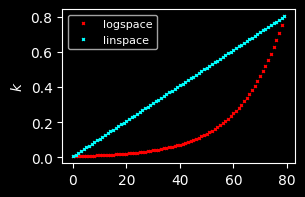

In [14]:
num_bins = 80
kedges1 = np.logspace(np.log10(2*np.pi/BoxSize), np.log10(kNyquist), num_bins)
kedges2 = np.linspace(2*np.pi/BoxSize, kNyquist, num_bins)
plt.figure(figsize = (3,2))
plt.plot(kedges1, ls='None', marker='x', color = "red", markersize = 2, label ='logspace')
plt.plot(kedges2, ls='None', marker='x', color = "cyan", markersize = 2, label = 'linspace')
plt.legend(fontsize = 8)
plt.ylabel(r'$k$') ;# plt.yscale('log')

In [27]:
## PYLIANS COMPUTATION ##
# PM
delta_pm_alt = get_delta(pos=pos_pm, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_pm_alt, Pk_pm_alt, _, _ = compute_Pk(delta_pm_alt, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# N-body (=target if no emulator)
delta_nb_alt = get_delta(pos=pos_nb, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_nb_alt, Pk_nb_alt, _, _ = compute_Pk(delta_nb_alt, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

# Cross-Spectrum
k_X_alt, Pk_X_alt, _, _ = compute_XPk(delta_pm_alt, delta_nb_alt, BoxSize=BoxSize, MAS=[MAS, MAS] , axis=0)
rk_alt = Pk_X_alt/np.sqrt(Pk_pm_alt*Pk_nb_alt)

## PYPOWER COMPUTATION ##
# With loading and saving data given computation times
num_bins = 80
interlacing_order = 2
kedges = np.linspace(0, kNyquist, num_bins)
ells = (0)

if os.path.exists(os.path.join('precomps', "pypower_pm_%i_bins.txt")) and os.path.exists(os.path.join(precomps, "pypower_nb_%ibins.txt")):
    k_pm = np.load(os.path.join('precomps', 'kpm_%i_bins.npy'%num_bins))
    k_nb = np.load(os.path.join('precomps', 'knb_%i_bins.npy'%num_bins))
    Pk_pm = np.load(os.path.join('precomps', "pypower_pm_%i_bins.npy"%num_bins))
    Pk_nb = np.load(os.path.join('precomps', "pypower_nb_%i_bins.npy"%num_bins))
    k_X = np.load(os.path.join('precomps', 'kX_%i_bins.npy'%num_bins))
    Pk_X = np.load(os.path.join('precomps', "pypower_X_%i_bins.npy"%num_bins))
else:
    start = time.time()
    result_pm = CatalogFFTPower(data_positions1=pos_pm, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')
    result_nb = CatalogFFTPower(data_positions1=pos_nb, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')
    result_X = CatalogFFTPower(data_positions1=pos_nb, data_positions2 = pos_pm, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=interlacing_order,position_type='pos')
    #result_pm.poles(remove_shotnoise=False)
    poles_pm = result_pm.poles
    poles_nb = result_nb.poles
    k_pm, Pk_pm = poles_pm(ell=ells, return_k=True, complex=False)
    k_nb, Pk_nb = poles_nb(ell=ells, return_k=True, complex=False)

    np.save(os.path.join('precomps', 'kpm_%i_bins.npy'%num_bins),k_pm)
    np.save(os.path.join('precomps', 'knb_%i_bins.npy'%num_bins),k_nb)
    np.save(os.path.join('precomps', "pypower_pm_%i_bins.npy"%num_bins), Pk_pm)
    np.save(os.path.join('precomps', "pypower_nb_%i_bins.npy"%num_bins), Pk_nb)

    poles_X = result_X.poles
    k_X, Pk_X = poles_X(ell=ells, return_k=True, complex=False)
    np.save(os.path.join('precomps', 'kX_%i_bins.npy'%num_bins),k_X)
    np.save(os.path.join('precomps', "pypower_X_%i_bins.npy"%num_bins), Pk_X)

    rk = poles_X(k=k_X, complex = False)[0,:]/np.sqrt(poles_nb(k=k_X, complex = False)[0,:]*poles_pm(k=k_X, complex = False)[0,:])
    #rk = Pk_X/np.sqrt(Pk_pm*Pk_nb)
    
    end = time.time()
    print("%.2f seconds of computation for both pypower calculations"%(end-start))




Using CIC mass assignment scheme
Time taken = 1.806 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Using CIC mass assignment scheme
Time taken = 1.845 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Computing power spectra of the fields...
Time FFTS = 0.56
Time loop = 0.36
Time taken = 0.93 seconds
371.64 seconds of computation for both pypower calculations


In [86]:
mesh_nb = CatalogMesh(data_positions=pos_nb,interlacing=interlacing_order, 
boxsize=BoxSize, nmesh=grid, resampler=MAS.lower(), position_type='pos')

mesh_pm = CatalogMesh(data_positions=pos_pm,interlacing=interlacing_order, 
boxsize=BoxSize, nmesh=grid, resampler=MAS.lower(), position_type='pos')

In [92]:
delta_nb = mesh_nb.to_mesh(compensate=True).value
delta_pm = mesh_pm.to_mesh(compensate=True).value

In [85]:
mesh_nb.to_mesh?

Signature: delta_nb.to_mesh(field=None, dtype=None, compensate=False)
Docstring:
Paint positions/weights to mesh.

Parameters
----------
field : string, default=None
    Field to paint to mesh, one of:

        - "data": data positions and weights
        - "shifted": shifted positions and weights (available only if shifted positions are provided)
        - "randoms": randoms positions and weights
        - "data-normalized_shifted": shifted positions and weights, renormalized (by alpha)
           such that their sum is same as data weights
        - "data-normalized_randoms": randoms positions and weights, renormalized (by alpha)
           such that their sum is same as data weights
        - "fkp": FKP field, i.e. data - alpha * (shifted if provided else randoms)
        - ``None``: defaults to "data" if no shifted/randoms, else "fkp"

dtype : string, dtype, default='f8'
    The data type of the mesh when painting, to override current :attr:`dtype`.

compensate : bool, default=Fals


Computing density field...
Expected mass = 1.1220728e+18
Computed mass = 1.1220731e+18
mass density = 8.81221e+10
0.087317914 < rho/<rho> < 23.772453

Computing density field...
Expected mass = 1.1222171e+18
Computed mass = 1.1222175e+18
mass density = 8.81221e+10
0.13087106 < rho/<rho> < 18.21459


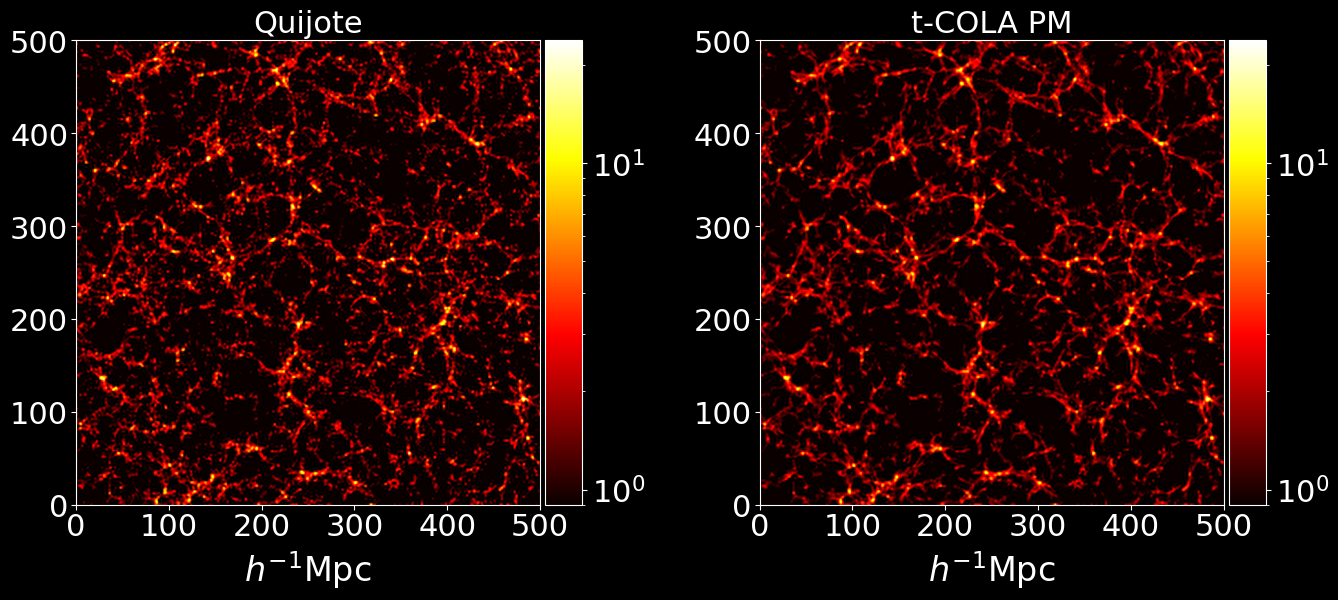

In [28]:
def plot_dFields(snapList, x_min, x_max, y_min, y_max, z_min, z_max, grid, ptypes, plane, MAS, scale, 
                 colmap, dmin, dmax, redshift, titleList):  
    """
    Plot projected density (or overdensity) field for each snapshot in snapList 
    """ 
    W_k = SL.FT_filter_2D(x_max - x_min, 0, grid, "Top-Hat", 5)
    P = len(snapList)
    save_density_field = False
    
    #Initialize axes depending on the number of snapshots to analyze
    if P%2 == 0 and P > 2:
      fig, axes = plt.subplots(int(P/2), int(P/2), sharex = False, sharey = False, squeeze = False, figsize = (12,12))
    else:
      fig, axes = plt.subplots(1, P, sharex = False, sharey = False, squeeze = False, figsize = (14, 9))
      axes.shape

    #To have the same colorbar scales for all plots, we need to compute all the overdensities
    OD_list = []
    for k in np.arange(0,P):
       dx, x, dy, y, overdensity = PL.density_field_2D(snapList[k], x_min, x_max, y_min, y_max, z_min, z_max, 
                                                       grid, ptypes, plane, MAS, save_density_field) # For Pylians3
       
       #overdensity[np.where(overdensity == 0)] = np.sort(np.unique(overdensity))[1] #prevents errors with log norm
       overdensity[np.where(overdensity < dmin)] = dmin
       overdensity[np.where(overdensity > dmax)] = dmax
       overdensity = SL.field_smoothing_2D(overdensity, W_k, 4)
       OD_list.append(overdensity)

    min_OD = min(overdensity.min() for overdensity in OD_list)
    max_OD = max(overdensity.max() for overdensity in OD_list)
    
    #For each snapshot  
    for k in np.arange(0, P):
        len_x, off_x, len_y, off_y, depth, BoxSize_slice = PL.geometry(snapList[k], plane, x_min, x_max, y_min, 
                                                                       y_max, z_min, z_max)
        #Compute overdensity field with Pylians plotting library
        ax = axes.flat[k] #flat not to bother with the 2D case
        ax.set_xlim([off_x, off_y+len_x])  #set the range for the x-axis
        ax.set_ylim([off_y, off_y+len_y])  #set the range for the y-axis
        ax.set_xlabel(r'$h^{-1}{\rm Mpc}$',fontsize= 24, labelpad = 5)  #x-axis label     
        ax.set_title(titleList[k], fontsize = 22)
        ax.tick_params(axis='x', which='major', pad=2, labelsize = 22)
        ax.tick_params(axis='y', which='major', pad=2, labelsize = 22)
        
        if scale == "linear":
            ca = ax.imshow(OD_list[k], cmap = plt.get_cmap(colmap),origin='lower',
                     extent=[off_x, off_x+len_x, off_y, off_y+len_y],
                     interpolation='sinc',
                     vmin=min_OD,vmax=max_OD)
            
        else:   
            ca = ax.imshow(OD_list[k], cmap = plt.get_cmap(colmap),origin='lower',
                     extent=[off_x, off_x+len_x, off_y, off_y+len_y],
                     interpolation='sinc',
                     norm = LogNorm(vmin=min_OD, vmax=max_OD))
        
        #next lines adjust the colorbar dimensions next to the subplot
        divider = make_axes_locatable(ax)
        cad = divider.append_axes("right", size="8%", pad=0.05)
        plt.subplots_adjust(bottom = 0.1, top = 0.9, left = 0.09, right = 0.94, wspace = 0.35)
        cbar = plt.colorbar(ca, cax=cad)
        cbar.ax.tick_params(axis = "both", labelsize = 22)

snapList = [nbody, app]
# For plotting
indicateNyquist = False
dmin = 0.9 ;dmax = 80
#%% 2D PROJECTED OVERDENSITY FIELD 
x_min = 0.0;  x_max = 500.0
y_min = 0.0;  y_max = 500.0
z_min = 40.0;  z_max = 90.0

plane = 'XY'
scale = 'log' #'linear' or 'log'
colmap = 'hot'
axList = ["Quijote", "t-COLA PM"]

plot_dFields(snapList, x_min, x_max, y_min, y_max, z_min, z_max, grid, ptype, plane, MAS, scale, colmap,
                dmin, dmax, redshift, axList)

In [29]:
# Emulate P(k)
pk_halofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial',
                extrapolate=True, which_params='Bartlett', add_correction=False)

pk_syrenhalofit = syrenhalofit.run_halofit(k_pm, sigma8=cosmology['sigma_8'], Om=cosmology['Omega_m'], 
                    Ob=cosmology['Omega_b'], h=cosmology['h'], ns=cosmology['n_s'], a=a, emulator='fiducial', 
                    extrapolate=True, which_params='Bartlett', add_correction=True)



/home/x-nchartier/miniconda3/envs/pkcorr/lib/python3.10/site-packages/symbolic_pofk/linear.py:244: UserWarning: Using Bartlett et al. formula outside tested regime. Due to problems with the Colossus Eisenstein & Hu fit on                 large scales (typically a 2 percent offset), it is strongly recommended to use extrapolate=False.
  warnings.warn(


In [30]:
# Pylians uses the diagonal of the cube for kmax, not k Nyquist !
print(k_pm.max())
print(k_pm.shape)
print(np.pi *grid/BoxSize)
print(np.pi *grid/BoxSize * np.sqrt(3))

nan
(79,)
0.8042477193189871
1.3929979117318794


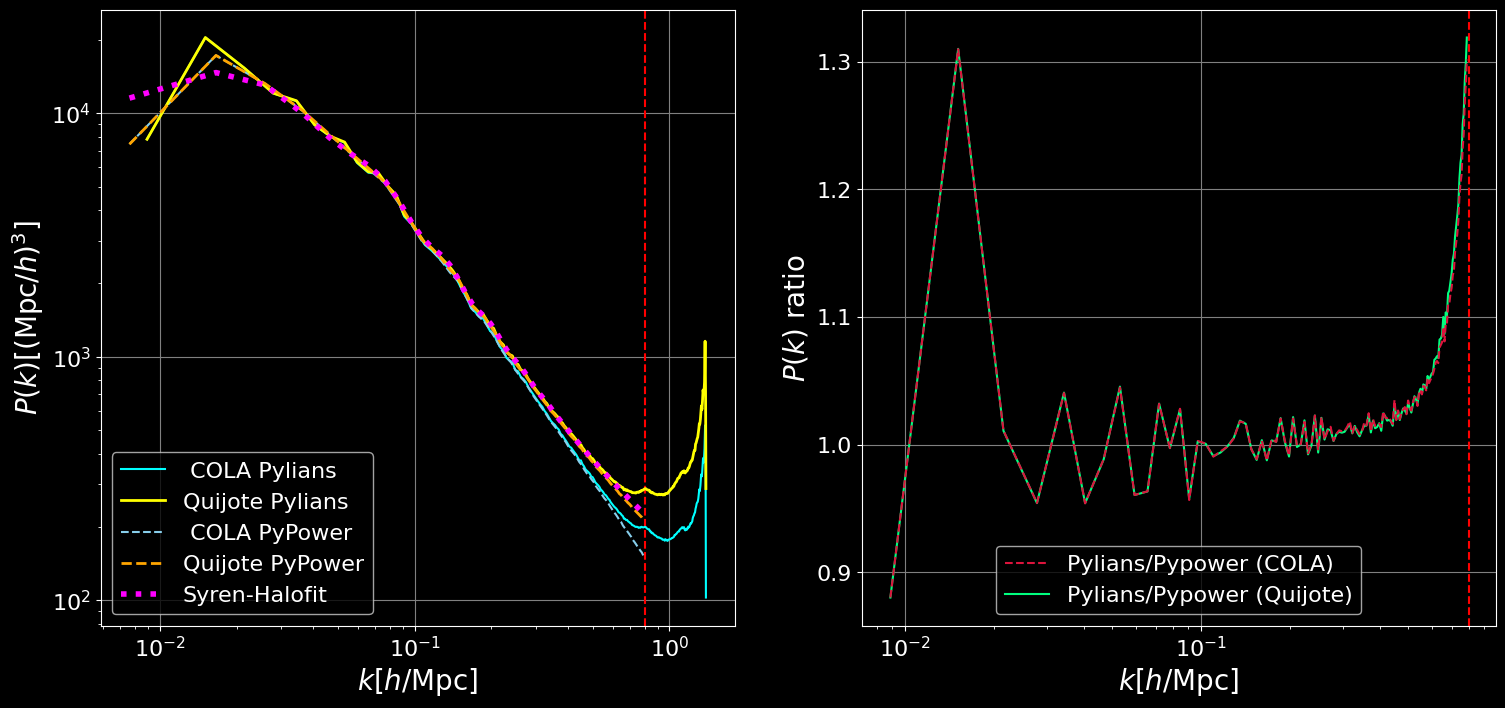

In [40]:
fig, axes = plt.subplots(figsize = (18,8), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]; ax2 = axes[1]
ax1.plot(k_pm_alt, Pk_pm_alt, label=" COLA Pylians", zorder = 3, color = "cyan")
ax1.plot(k_nb_alt, Pk_nb_alt, label='Quijote Pylians', lw = 2, color = "yellow", zorder = 4)
ax1.plot(k_pm, Pk_pm, label=" COLA PyPower", zorder = 3, color = "skyblue", ls = "--")
ax1.plot(k_nb, Pk_nb, label='Quijote PyPower', lw = 2, color = "orange", zorder = 4, ls = "--")
ax1.plot(k_pm, pk_syrenhalofit, label='Syren-Halofit', color = "magenta", ls = "dotted", zorder = 8, lw = 4)
ax1.legend(fontsize = 16)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 20)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 20)
ax1.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax1.tick_params(labelsize = 16)

ax2.plot(k_pm_alt, Pk_pm_alt/np.interp(k_pm_alt, k_pm, Pk_pm),label='Pylians/Pypower (COLA)', zorder = 5, color = "crimson", ls = "--")
ax2.plot(k_nb_alt, Pk_nb_alt/np.interp(k_nb_alt, k_nb, Pk_nb),label='Pylians/Pypower (Quijote)', zorder = 4, color = "springgreen")
#ax2.plot(k_pm, Pk_pm/poles_pm(k=k_pm, complex = False)[0,:], label='Pylians/Pypower COLA', zorder = 4, color = "crimson", ls = "--")
#ax2.plot(k_nb, Pk_nb/poles_nb(k=k_nb, complex = False)[0,:], label='Pylians/Pypower COLA', zorder = 3, color = "springgreen")
ax2.legend(fontsize = 16)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 20)
ax2.set_yscale("linear")
ax2.set_xscale("log")
ax2.set_ylabel(r"$P(k)$" + " ratio", fontsize = 20)
ax2.grid(color = "grey")
ax2.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax2.tick_params(labelsize = 16)

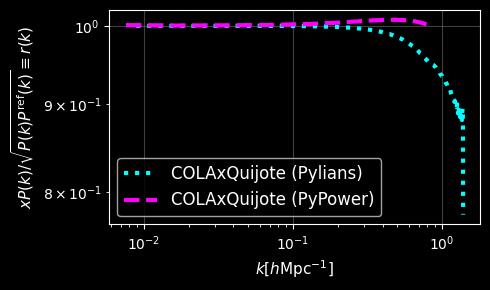

In [93]:
fig, axes = plt.subplots(1,1, figsize = (5,3))
axes.plot(k_X_alt, rk_alt, ':', label='COLAxQuijote (Pylians)', zorder= 10, lw = 3, color = "cyan")
axes.plot(k_X, rk, '--', label='COLAxQuijote (PyPower)', zorder= 10, lw = 3, color = "magenta")
axes.set_xscale("log")
axes.set_yscale("log")
axes.legend(fontsize = 12)
axes.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
axes.set_ylabel(r"$xP(k)/\sqrt{P(k)P^{\mathrm{ref}}(k)} \equiv r(k)$", fontsize = 11, rotation = 90)
axes.grid(color = "gray", alpha = 0.5)
plt.tight_layout()

# 2) Dark matter particles - perfect correlation case

$\Phi(k) = \frac{\gamma_k}{k^2} \Delta_k$


If we take the expectation with respect to Delta, power spectrum, as well as bispectum and trispectrum terms appear

\begin{align}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} &\approx (2\pi)^3P(k) + \gamma_k^2(2\pi)^3P(k) +\frac{1}{V^2} \sum_{\mathbf{q},\mathbf{q'}} \frac{\gamma_{q'}\gamma_{q}}{q^2 q'^{2}}(\mathbf{k} \cdot \mathbf{q}) (\mathbf{k} \cdot \mathbf{q'}) \mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}
 \Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}\Delta_{\mathbf{\textcolor{red}{k-q'}}}^{\ast}] \nonumber \\
&+ 2 \operatorname{Re}\left[ (2\pi)^3 \gamma_k P(k) +\frac{1}{V} \sum_{\mathbf{q}}(\mathbf{k} \cdot \mathbf{q}) \gamma_k \frac{\gamma_q}{q^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}] \right. \nonumber \\
 &+\left. \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2}
\mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}]
    +\frac{1}{2V} \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot (\mathbf{k} -\mathbf{q}))\frac{\gamma_q}{q^2} \frac{\gamma_{|k-q|}}{|k-q|^2} \mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast} \Delta_{\mathbf{k-q}}^{\ast}]
 \right. \nonumber \\
 &+ \left. \frac{1}{2V^2} \sum_{\mathbf{q}, \mathbf{q'}} (\mathbf{k} \cdot \mathbf{q})(\mathbf{k} \cdot \mathbf{q'})\frac{\gamma_q}{q^2} \frac{\gamma_q'}{q'^2}\mathbb{E}_{\Delta}[\Delta_{\mathbf{k}}\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{q'}}^{\ast} \Delta_{\mathbf{\textcolor{red}{k-q-q'}}}^{\ast}] \right]
\end{align}

**Question**

Can we afford dropping bispectrum and trispectrum terms and simply solving for the polynomial below ? 
\begin{equation}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\Delta} = P(k) + \gamma_k^2 P(k) + 2 \gamma_k P(k) 
\end{equation}

## 2-1) With only the second-order system above


In [70]:
# If emulator, the target Power spectrum is a mean emulator calculation
emulator = False
Pk_target = pk_syrenhalofit if emulator else Pk_nb

high_roots = True # take roots_e[:,1].real if True, roots_e[:,0].real otherwise

tstr = "emul" if emulator else "sim"
rstr = "posroots" if high_roots else "negroots"

fig_fold = os.path.join(basedir, appstr, "corr_%s_%s"%(tstr, rstr))

if not os.path.exists(fig_fold):
    os.makedirs(os.path.join(fig_fold), exist_ok=False)

# Limit the analysis to k Nyquist
kN = np.pi *grid/BoxSize
#kN = k_nb.max()
inds = np.where(k_nb <= kN)
k = k_nb[inds]
inds_alt = np.where(k_nb_alt <= kN)
k_alt = k_nb_alt[inds_alt]
print(k.shape)

(78,)


(78, 3)


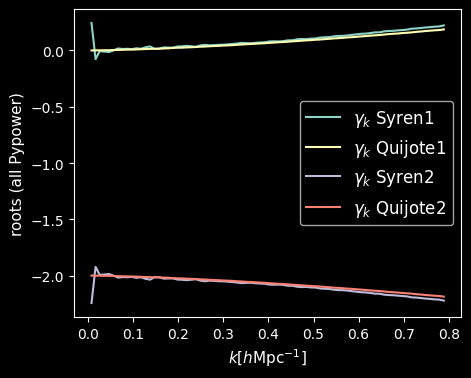

In [71]:
# With gamma convention
roots_nb, coeffs_nb=get_roots_gamma(k, Pk_pm[inds], Pk_nb[inds])
roots_nb_alt, coeffs_nb_alt=get_roots_gamma(k_alt, Pk_pm_alt[inds_alt], Pk_nb_alt[inds_alt])
roots_e, coeffs_e=get_roots_gamma(k, Pk_pm[inds], pk_syrenhalofit[inds])

# "Positive" roots
gamma_k_e1 = roots_e[:,1].real
gamma_k_nb1 = roots_nb[:,1].real
gamma_k_nb1_alt = roots_nb_alt[:,1].real

# "Lower" roots
gamma_k_e2 = roots_e[:,0].real
gamma_k_nb2 = roots_nb[:,0].real
print(coeffs_e.shape)

fig, ax = plt.subplots(figsize = (5,4), ncols = 1, nrows= 1)
ax.plot(k, gamma_k_e1, label=r'$\gamma_k$' + " Syren1")
ax.plot(k, gamma_k_nb1, label=r'$\gamma_k$' + " Quijote1")
ax.plot(k, gamma_k_e2, label=r'$\gamma_k$' + " Syren2")
ax.plot(k, gamma_k_nb2, label=r'$\gamma_k$' + " Quijote2")
ax.legend(fontsize = 12)
ax.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
ax.set_ylabel(r"roots (all Pypower)", fontsize = 11)
#plt.tight_layout()
plt.savefig(os.path.join(fig_fold, "gammak_roots.pdf"), bbox_inches = "tight")

# Sets the roots for later with the same variable names
if emulator:
    Pk_target = pk_syrenhalofit
    gamma_k = gamma_k_e1 if high_roots else gamma_k_e2
    coeffs = coeffs_e
    roots = roots_e
else:
    Pk_target = Pk_nb
    gamma_k = gamma_k_nb1 if high_roots else gamma_k_nb2
    coeffs = coeffs_nb
    roots = roots_nb

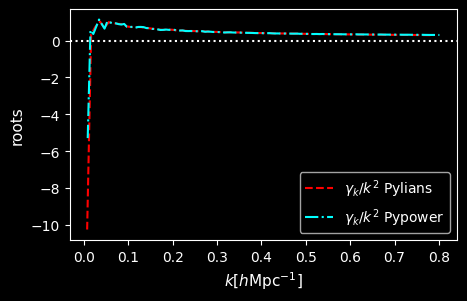

In [72]:
fig = plt.figure(figsize = (5,3))
plt.plot(k, roots_nb[:,1].real/k**2, label = r"$\gamma_k/k^2$" + " Pylians", ls = "--", zorder =3, color = "red")
plt.plot(k_alt, roots_nb_alt[:,1].real/k_alt**2, label = r"$\gamma_k/k^2$" + " Pypower", ls = "dashdot", zorder =4, color = "cyan")
plt.legend(fontsize = 12)
plt.xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
plt.ylabel(r"roots", fontsize = 11)
plt.axhline(0, ls = "dotted")
# plt.loglog()
plt.legend()

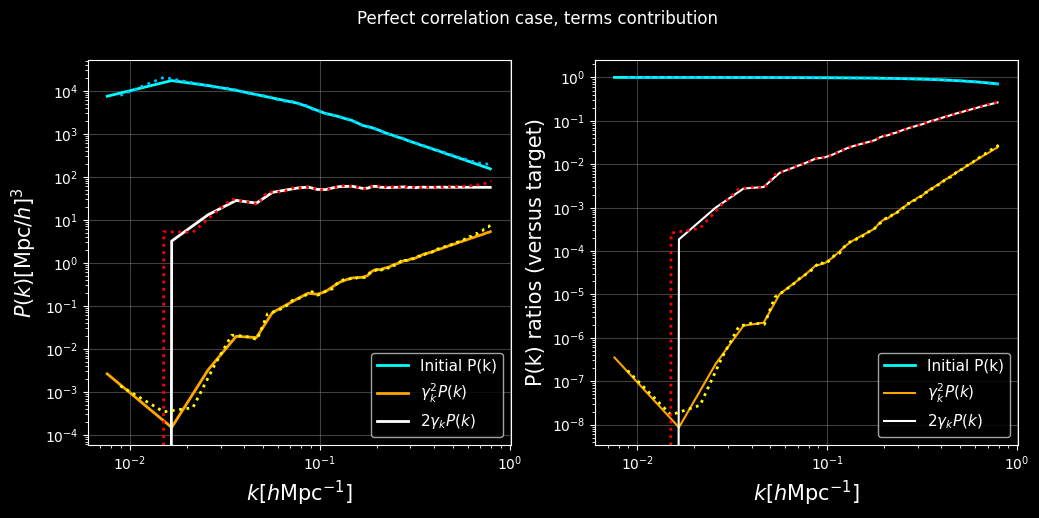

In [80]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

#ax1.plot(k, Pk_nb[inds], color = "magenta", lw = 2, label = "Target Quijote P(k)")
ax1.plot(k, Pk_pm[inds], color = "cyan", lw = 2, label = "Initial P(k)", zorder = 5)
ax1.plot(k, coeffs[:,0]*(roots[:,1].real)**2, color = "orange", lw = 2, label = r"$\gamma_k^2P(k)$")
ax1.plot(k, coeffs[:,1]*roots[:,1].real, color = "white", lw = 2, label = r"$2\gamma_k P(k)$")
ax1.plot(k_alt, Pk_pm_alt[inds_alt], color = "deepskyblue", lw = 2, zorder = 5, ls = ':')
ax1.plot(k_alt, coeffs_nb_alt[:,0]*(roots_nb_alt[:,1].real)**2, color = "yellow", lw = 2, ls = ':')
ax1.plot(k_alt, coeffs_nb_alt[:,1]*roots_nb_alt[:,1].real, color = "red", lw = 2, ls = ':')
ax1.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =15)
ax1.set_ylabel(r"$P(k)[\mathrm{Mpc}/h]^3$", fontsize =15)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

#ax2.plot(k, Pk_nb[inds]/Pk_nb[inds], color = "magenta", lw = 2, label = "Target Quijote P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_nb[inds], color = "cyan", lw = 2, label = "Initial P(k)", zorder = 5)
ax2.plot(k, coeffs[:,0]*(roots[:,1].real)**2/Pk_nb[inds], color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax2.plot(k, coeffs[:,1]*roots[:,1].real/Pk_nb[inds], color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax2.plot(k_alt, Pk_pm_alt[inds_alt]/Pk_nb_alt[inds_alt], color = "deepskyblue", lw = 2, zorder = 5, ls=":")
ax2.plot(k_alt, coeffs_nb_alt[:,0]*(roots_nb_alt[:,1].real)**2/Pk_nb_alt[inds_alt], color = "yellow", lw = 2, ls=":")
ax2.plot(k_alt, coeffs_nb_alt[:,1]*roots_nb_alt[:,1].real/Pk_nb_alt[inds_alt], color = "red", lw = 2, ls=":")
ax2.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =15)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =15)
ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution")
plt.savefig(os.path.join(fig_fold, "Pk_setup_comparison.pdf"), bbox_inches = "tight")

### With delta from Pylians

In [94]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# Compute MAS correction factors
MAS_factor_kx = MAS_correction(scale* fx* np.pi/2.*1./kN, MAS_index)
MAS_factor_ky = MAS_correction(scale* fy* np.pi/2.*1./kN, MAS_index)
MAS_factor_kz = MAS_correction(scale * fz* np.pi/2.*1./kN , MAS_index)
MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

# MY COMPUTATION
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = delta_pm_alt.astype(prec_in) # PYLIANS
delta_pm_fourier = fftw_plan(a_in,a_out)

delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift*MAS_factor

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale
print(rad.min(), rad.max())

fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
print(np.isclose(rad,k_radius).all())

weights1D = gamma_k_nb1_alt#roots[:,1].real/(k**2)
# Put gamma_k weights in 3D
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k_alt, weights1D) # PYLIANS

# Finally compute Phi_k
phi_k = weights_grid * delta_k

# MY RECIPE
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_k

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_alt = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_alt = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_alt = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
comoving_length = length_grid + cell/2
arr_interp = length_grid

0.0 1.3929979117318794
True


### With delta from Pypower
I still use delta from Pylians for now, because I do not understand how the MAS correction works in Pypower.

In [101]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# Compute MAS correction factors
MAS_factor_kx = MAS_correction(scale* fx* np.pi/2.*1./kN, MAS_index)
MAS_factor_ky = MAS_correction(scale* fy* np.pi/2.*1./kN, MAS_index)
MAS_factor_kz = MAS_correction(scale * fz* np.pi/2.*1./kN , MAS_index)
MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

# MY COMPUTATION
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = delta_pm_alt.astype(prec_in)
delta_pm_fourier = fftw_plan(a_in,a_out)

delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift *MAS_factor

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale
print(rad.min(), rad.max())

fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
print(np.isclose(rad,k_radius).all())

weights1D = gamma_k#roots[:,1].real/(k**2)
# Put gamma_k weights in 3D
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D)

# Finally compute Phi_k
phi_k = weights_grid * delta_k

# MY RECIPE
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_k

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
comoving_length = length_grid + cell/2
arr_interp = length_grid

0.0 1.3929979117318794
True


### Misc.

In [64]:
#CHANGING THE WEIGHTS FOR VISUAL CUE

weights1D10 = 10*gamma_k#roots[:,1].real/(k**2)
# Put gamma_k weights in 3D
print(k.max())
weights_grid = np.empty(delta_k.shape)
weights_grid10 = fill_fourier_grid(weights_grid, k_radius , k, weights1D10)

# Finally compute Phi_k
phi_k10 = weights_grid10 * delta_k

# MY RECIPE
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_k10
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_k10
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_k10

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_alt10 = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_alt10 = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_alt10 = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

0.7889833940298195


0.17763522
10.63588
float32


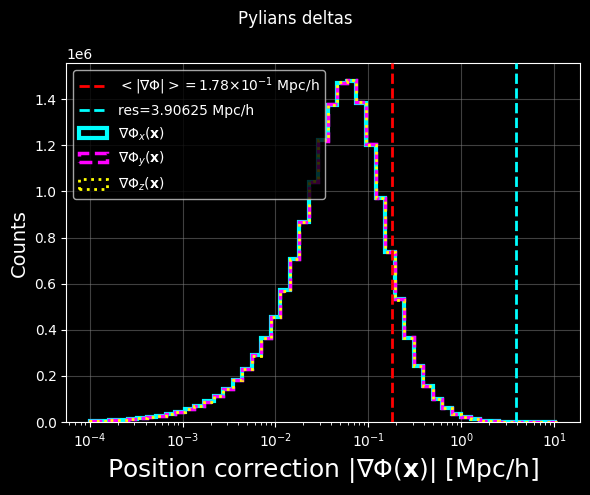

In [96]:
mean_disp = np.mean(np.sqrt(a_x_alt**2 + a_y_alt**2+a_z_alt**2 ))
max_disp = np.sqrt(a_x_alt**2 + a_y_alt**2+a_z_alt**2 ).max()
print(mean_disp)
print(max_disp)
print(a_x_alt.dtype)
loghist = False
denshist = False
cumhist = 0
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 50)
fig, ax = plt.subplots(1,1, figsize = (6,5))
ax.axvline(x = mean_disp,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_disp))
ax.axvline(x = BoxSize/grid,zorder = 5, color = "cyan", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax.hist(np.abs(a_x_alt.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$\nabla \Phi_x(\mathbf{x})$", cumulative=cumhist , lw = 3., color = "cyan")
ax.hist(np.abs(a_y_alt.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2.5, density = denshist, label = r"$\nabla \Phi_y(\mathbf{x})$", cumulative=cumhist, linestyle = "dashed", zorder = 3, color = "magenta" )
ax.hist(np.abs(a_z_alt.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density =denshist, label = r"$\nabla \Phi_z(\mathbf{x})$", cumulative=cumhist ,
       linestyle = "dotted", zorder = 4, color = "yellow")
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax.set_xscale("log")
ax.legend(fontsize = 10)
ax.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax.set_ylabel("density", fontsize = 14)
else:
    ax.set_ylabel("Counts", fontsize = 14)
ax.grid(color = "gray", alpha = 0.5)
plt.suptitle("Pylians deltas")
plt.tight_layout()
#ax.set_xlim(left = 0, right = 60.)

0.16748431
10.104465
float32


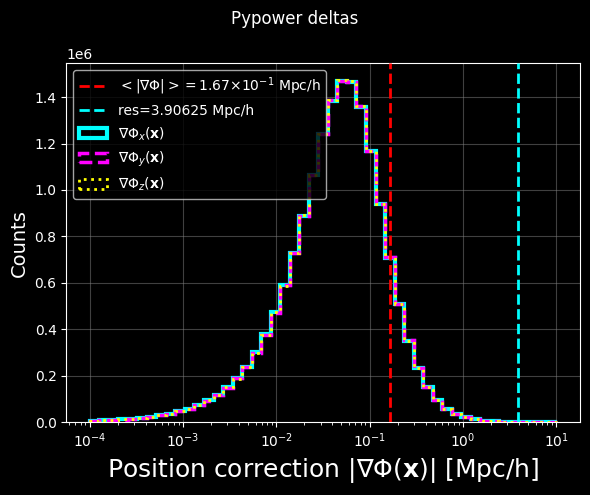

In [102]:
mean_disp = np.mean(np.sqrt(a_x**2 + a_y**2+a_z**2 ))
max_disp = np.sqrt(a_x**2 + a_y**2+a_z**2 ).max()
print(mean_disp)
print(max_disp)
print(a_x_alt.dtype)
loghist = False
denshist = False
cumhist = 0
#bins = 1000
bins = np.logspace(-4, np.log10(max_disp), 50)
fig, ax = plt.subplots(1,1, figsize = (6,5))
ax.axvline(x = mean_disp,zorder = 5, color = "red", linewidth = 2 ,linestyle = "dashed", label = r"$<|\nabla \Phi|> = $" + "%s Mpc/h"%sci_notation(mean_disp))
ax.axvline(x = BoxSize/grid,zorder = 5, color = "cyan", linewidth = 2 ,linestyle = "dashed", label = r"res=" + "%s Mpc/h"%(BoxSize/grid))
ax.hist(np.abs(a_x.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
         density = denshist, label = r"$\nabla \Phi_x(\mathbf{x})$", cumulative=cumhist , lw = 3., color = "cyan")
ax.hist(np.abs(a_y.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2.5, density = denshist, label = r"$\nabla \Phi_y(\mathbf{x})$", cumulative=cumhist, linestyle = "dashed", zorder = 3, color = "magenta" )
ax.hist(np.abs(a_z.flatten()),bins=bins, log = loghist, histtype="step",rwidth = 0.8, 
        linewidth = 2, density =denshist, label = r"$\nabla \Phi_z(\mathbf{x})$", cumulative=cumhist ,
       linestyle = "dotted", zorder = 4, color = "yellow")
#ax.vlines(x = LCDMbest, ymin = 0, ymax = 2e3, color = "red", linewidth = 2 ,linestyle = "dashed", label = "LCDM best")
ax.set_xscale("log")
ax.legend(fontsize = 10)
ax.set_xlabel("Position correction " +  r"$|\nabla\Phi (\mathbf{x})|$" + " [Mpc/h]", fontsize = 18)
if denshist:
    ax.set_ylabel("density", fontsize = 14)
else:
    ax.set_ylabel("Counts", fontsize = 14)
ax.grid(color = "gray", alpha = 0.5)
plt.suptitle("Pypower deltas")
plt.tight_layout()
#ax.set_xlim(left = 0, right = 60.)

In [104]:
# MINE: TRILINEAR INTERPOLATION
prec_in = "float32"
pos_corrected= np.empty(pos_pm.shape).astype(prec_in)
pos_corrected_alt= np.empty(pos_pm.shape).astype(prec_in)
pos_corrected_noth= np.empty(pos_pm.shape).astype(prec_in)
#pos_corrected_10= np.empty(pos_pm.shape).astype(prec_in)

pos_corrected, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected, a_x.astype("float32"), a_y.astype("float32"), a_z.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

pos_corrected_alt, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_alt, a_x_alt.astype("float32"), a_y_alt.astype("float32"), a_z_alt.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

pos_corrected_noth, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_noth, a_x_alt.astype("float32"), a_y_alt.astype("float32"), a_z_alt.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize)

#pos_corrected_10, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_10, a_x_alt10.astype("float32"), a_y_alt10.astype("float32"), a_z_alt10.astype("float32"),
#                                            arr_interp, arr_interp, arr_interp, BoxSize)

delta_corrected=get_delta(pos=pos_corrected, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected, Pk_disp, _, _ = compute_Pk(delta_corrected, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

delta_corrected_alt=get_delta(pos=pos_corrected_alt, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected_alt, Pk_disp_alt, _, _ = compute_Pk(delta_corrected_alt, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

#delta_corrected_10=get_delta(pos=pos_corrected_10, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
#k_corrected_10, Pk_disp_10, _, _ = compute_Pk(delta_corrected_10, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

delta_corrected_noth=get_delta(pos=pos_corrected_noth, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected_noth, Pk_disp_noth, _, _ = compute_Pk(delta_corrected_noth, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)

0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256

Using CIC mass assignment scheme
Time taken = 1.809 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Using CIC mass assignment scheme
Time taken = 1.810 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds

Using CIC mass assignment scheme
Time taken = 1.808 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds


In [105]:
result_corr = CatalogFFTPower(data_positions1=pos_corrected, boxsize=BoxSize, nmesh=grid, 
                                resampler= MAS.lower(),
                                edges=kedges, ells=ells, interlacing=2,position_type='pos')
poles_corr = result_corr.poles

In [109]:
Po.shape

(1, 79)

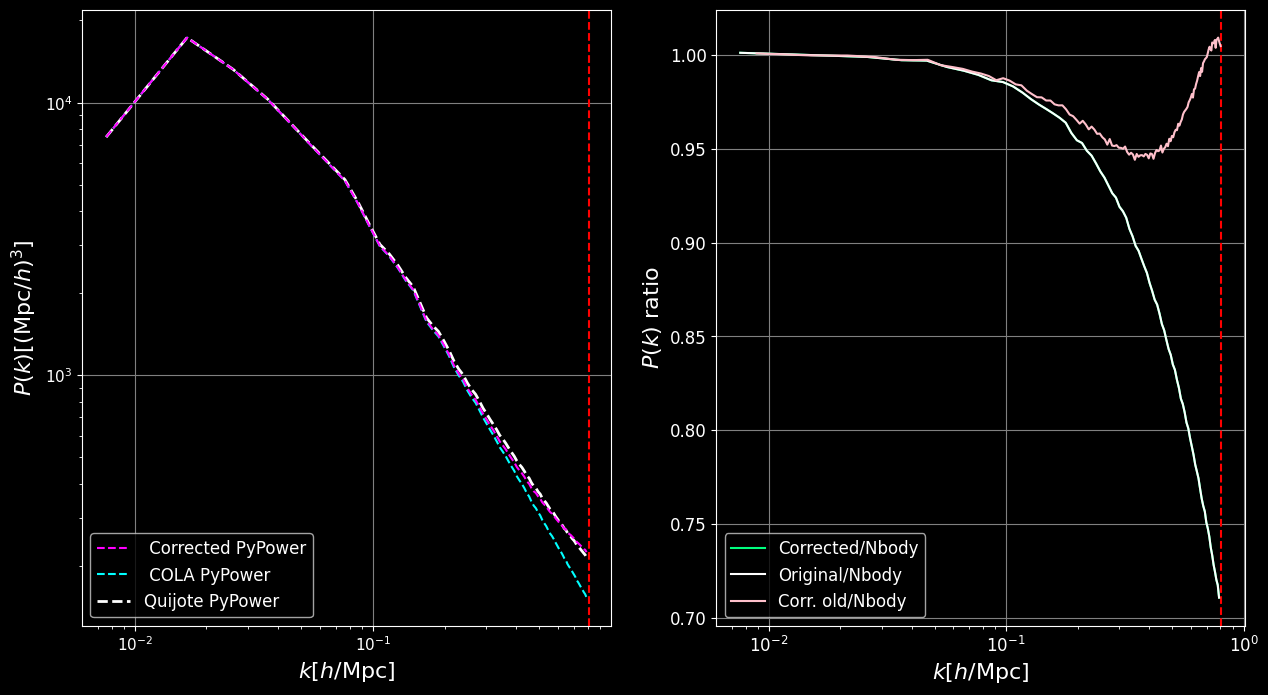

In [115]:
fig, axes = plt.subplots(figsize = (15,8), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]; ax2 = axes[1]
#ax1.plot(k_pm, Pk_pm, label=" COLA Pylians", zorder = 3, color = "cyan")
#ax1.plot(k_nb, Pk_nb, label='Quijote Pylians', lw = 2, color = "white", zorder = 4)
ax1.plot(*poles_corr(ell=ells, return_k=True, complex=False), label=" Corrected PyPower", zorder = 5, color = "magenta", ls = "--")
ax1.plot(k_pm, Pk_pm, label=" COLA PyPower", zorder = 3, color = "cyan", ls = "--")
ax1.plot(k_nb, Pk_nb, label='Quijote PyPower', lw = 2, color = "white", zorder = 4, ls = "--")
#ax1.plot(k_pm, pk_syrenhalofit, label='Syren-Halofit (ref.)', color = "magenta", ls = "dotted", zorder = 5)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax1.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax1.tick_params(labelsize = 11)

ko, Po = poles_pm(return_k=True, complex=False)
#kk, Pkk = poles_nb(complex = False, return_k = True)
#kcc, Pcc = poles_corr(complex = False, return_k = True)
#ax2.plot(k_pm, Pk_pm/poles_pm(k=k_pm, complex = False)[0,:], label='Pylians/Pypower COLA', zorder = 4, color = "crimson", ls = "--")
ax2.plot(ko, Po[0,:]/Pk_nb, label='Corrected/Nbody', zorder = 3, color = "springgreen")
ax2.plot(k_nb, Pk_pm/Pk_nb, label='Original/Nbody', zorder = 3, color = "white")
ax2.plot(k_corrected_alt[inds_alt], Pk_disp_alt[inds_alt]/Pk_nb_alt[inds_alt], label='Corr. old/Nbody', zorder = 3, color = "pink")
ax2.legend(fontsize = 12)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax2.set_yscale("linear")
ax2.set_xscale("log")
ax2.set_ylabel(r"$P(k)$" + " ratio", fontsize = 16)
ax2.grid(color = "grey")
ax2.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kNyquist)
ax2.tick_params(labelsize = 12)

ValueError: x and y must have same first dimension, but have shapes (221,) and (79,)

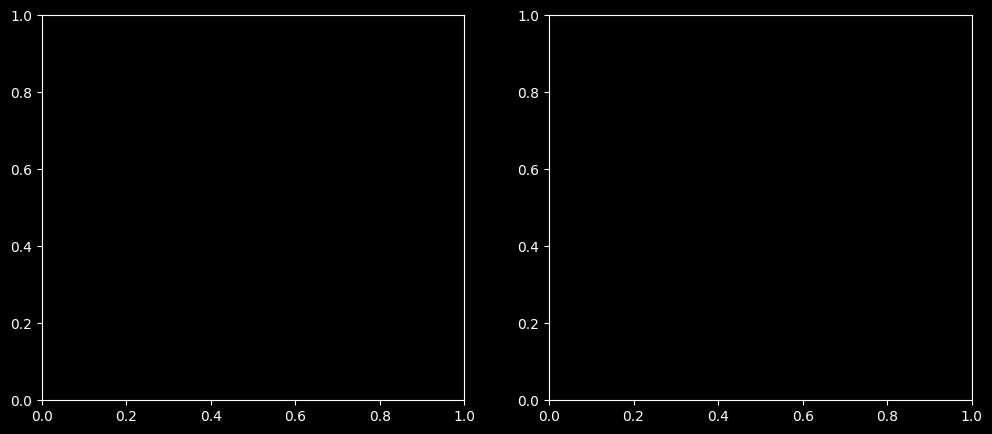

In [67]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

# temporary fix
kplot = k_corrected_alt.copy()

ax1.plot(kplot, Pk_target, color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(kplot, Pk_pm, color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(kplot, Pk_disp_alt, color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
#ax1.plot(kplot, Pk_disp_10, color = "yellow", lw = 1.5, label = "Corrected P(k) x10", ls = "dotted", zorder = 5)
ax1.plot(kplot, Pk_disp_noth, color = "white", lw = 1.5, label = "Corrected P(k), no thresh.", ls = "dotted", zorder = 5)
ax1.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kN)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(kplot, Pk_target/Pk_target, color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(kplot, Pk_pm/Pk_target, color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax2.plot(kplot, Pk_disp_alt/Pk_target, color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
#ax2.plot(kplot, Pk_disp_10/Pk_target, color = "yellow", lw = 1.5, label = "Corrected P(k) x10", ls = "dotted", zorder = 5)
ax2.plot(kplot, Pk_disp_noth/Pk_target, color = "white", lw = 1.5, label = "Corrected P(k) no thresh,", ls = "dotted", zorder = 5)
ax2.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
#ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("linear")
ax2.grid(color = "grey", alpha = 0.5)
plt.subplots_adjust(wspace = 0.3)
plt.suptitle("Perfect correlation case, Dark Matter Particles")
ax2.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kN)

## 2-2) Bispectrum Term contribution ?
We -will be studying the remaining term that is linear in $\gamma_k$)

With the conjugate-symmetry property for the FT of a real-valued field $\Delta (\mathbf{x})$, we have 

\begin{equation}
\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast} = \Delta_{\mathbf{-q}}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{q-k}}}\,,
\end{equation}
so that when we take the expectation over $\Delta$ and sum over $q$, the contribution is non-zero because $-q+k+k-q$ always forms a closed triangle.

$\frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2}
\mathbb{E}_{\Delta}[\Delta_{\mathbf{q}}^{\ast}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{k-q}}}^{\ast}]$

Let's compute the term, with $|\mathbf{k}-\mathbf{q}| = \sqrt{k^2 + q^2 - 2kq \cos \theta}$,

\begin{equation}
     \text{"Bispectrum Term"}(k) \equiv \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2}
\mathbb{E}_{\Delta}[ \Delta_{\mathbf{-q}}\Delta_{\mathbf{k}}\Delta_{\mathbf{\textcolor{red}{q-k}}}] = \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) \frac{\gamma_q}{q^2}(2\pi)^3 B(q,k, |\mathbf{k}-\mathbf{q}|)
\end{equation}.

First, we focus on the angular integral form, similarly to the uncorrelated case with $(\mathbf{k} \cdot \mathbf{q}) = k q \cos \theta$, where we compute the term J for k fixed:
<!-- \begin{align}
J(k,q) &= \int d\Omega_\mathbf{k} \int d\Omega_\mathbf{q} \, k q \cos \theta \frac{\gamma_q}{q^2}B(q,k, |\mathbf{k}-\mathbf{q}|) \nonumber \\
&=  \int_0^{2\pi} d\phi_k \int_0^{\pi} d\theta_k \sin \theta_k \int_0^{2\pi} d\phi_q \int_0^{\pi} d\theta_q \sin \theta_q k q \cos \theta \frac{\gamma_q}{q^2}B(q,k, |\mathbf{k}-\mathbf{q}|)\\
\end{align} -->

\begin{align}
J(k,q, \theta) &=  \int d\Omega_\mathbf{q} \, k q \cos \theta \frac{\gamma_q}{q^2}B(q,k, |\mathbf{k}-\mathbf{q}|) \nonumber \\
&=  \int_0^{2\pi} d\phi_q \int_0^{\pi} d\theta_q \sin \theta_q k q \cos \theta \frac{\gamma_q}{q^2}B(q,k, |\mathbf{k}-\mathbf{q}|)\\
\end{align}
The integrand only depends on the angle between the wavevectors and as for the previous demonstration, the integration over $\hat{\mathbf{q}}$ will give the same result for any fixed $\hat{\mathbf{k}}$. 
We can also choose $\hat{\mathbf{k}}$ along  
$\hat{\mathbf{z}}$ so that $\theta = \theta_q$

By isolating the integrand part than only depends on the angle between wavevectors, we get 
\begin{align}
J(k,q, \theta)&=  2\pi \frac{k}{q}\gamma_q  \int_0^{\pi} d\theta \sin \theta\cos \theta B(q,k,\sqrt{k^2 + q^2 - 2kq \cos \theta})\nonumber \\
&=2\pi \frac{k}{q}\gamma_q  \int_0^{\pi} -d(\cos \theta)\cos \theta B(q,k,\sqrt{k^2 + q^2 - 2kq \cos \theta})\nonumber \\
&=2\pi \frac{k}{q}\gamma_q  \int_{-1}^{1} y B(q,k,\sqrt{k^2 + q^2 - 2kq y})dy
\end{align}
with the change of variable $y = \cos \theta$.
Then, we include the missing $\frac{(2\pi)^3}{V}$ factor to the above, and most importantely integrate over $q^2dq$.

\begin{equation}
     \text{"Bispectrum Term"}(k) = \frac{(2\pi)^3}{V}\int_0^{q=k_{\mathrm{max}}} q'^2 J(k,q',\theta)dq' = \frac{(2\pi)^3}{V}2\pi k\frac{q^2}{2}\gamma_{q} \int_{-1}^{1} y B(q,k,\sqrt{k^2 + q^2 - 2kq y})dy
\end{equation}.

**Note**: because I divided by $(2\pi)^3$ the equation to solve without the bispec term, I need to not include this factor in the total sum.

In [23]:
pb.PolyBin3D?

Init signature:
pb.PolyBin3D(
    boxsize,
    gridsize,
    Pk=None,
    boxcenter=None,
    pixel_window='none',
    backend='mkl',
    nthreads=None,
    sightline='global',
    real_fft=True,
)
Docstring:     
Base class for PolyBin3D.

Inputs:
- boxsize: 3D box-size (with 1 or 3 components)
- gridsize: Number of Fourier modes per dimension (with 1 or 3 components)
- Pk (optional): Fiducial power spectrum monopole (including noise), in ordering {k, P_0(k)}. This is used for the ideal estimators and for creating synthetic realizations for the optimal estimators. If unset, unit power will be assumed.
- boxcenter (optional): Center of the 3D box (with 1 or 3 components). Default: None ( = [0,0,0])
- pixel_window (optional): Which voxel window function to deconvolve from the data. See self.pixel_windows for a list of options (including "none"). Default: "none"
- backend (optional): Which backend to use to compute FFTs. Options: "mkl" [requires mkl_fft].   
- nthreads (optional): How ma

In [24]:
pb.BSpec?

Init signature:
pb.BSpec(
    base,
    k_bins,
    lmax=0,
    mask=None,
    applySinv=None,
    k_bins_squeeze=None,
    include_partial_triangles=False,
    add_GIC=False,
    mask_IC=None,
    add_RIC=False,
    radial_bins_RIC=[],
    Pk_fid=None,
    mask_shot=None,
    applySinv_transpose=None,
)
Docstring:     
Class containing the bispectrum estimators.

Inputs:
- base: PolyBin base class
- k_bins: array of one-dimensional k bin edges (e.g., [0.01, 0.02, 0.03] would give two bins: [0.01,0.02] and [0.02,0.03]).
- lmax: (optional) maximum Legendre multipole, default: 0.
- mask: (optional) 3D mask, specifying the background density n(x,y,z).
- applySinv: (optional) function which weights the data field. This is only used in unwindowed estimators.
- k_bins_squeeze: (optional) array of one-dimensional squeezed bin edges. These can be used to compute squeezed triangles, giving a different kmax for short and long sides.
- include_partial_triangles: (optional) whether to include tria

In [26]:
start = time.time()
base = pb.PolyBin3D([BoxSize,BoxSize,BoxSize], # dimensions of box 
                    [grid,grid,grid], # dimensions of Fourier-space grid, 
                    boxcenter=[0,0,0], # center of simulation box
                    pixel_window='cic', # pixel window function
                    backend='fftw', # backend for performing FFTs ('fftw' or 'mkl' for cpu, 'jax' for gpu)
                    nthreads=8, # number of CPUs to parallelize across (not used for jax code)
                    sightline='global') # redshift-space axis
end = time.time()
print("%.1f seconds of computation"%(end-start))


# Dimensions: [1.00e+03, 1.00e+03, 1.00e+03] Mpc/h
# Center: [0.00e+00, 0.00e+00, 0.00e+00] Mpc/h
# Line-of-sight: global
# Cartesian grid: [256, 256, 256]
# Fundamental frequency: [0.0063, 0.0063, 0.0063] h/Mpc
# Nyquist frequency: [0.804, 0.804, 0.804] h/Mpc
# Pixel window: cic
# Using FFTW backend
1.3 seconds of computation


0.006283185307179587
0.006286900543131258


Text(0, 0.5, 'np.diff(k)')

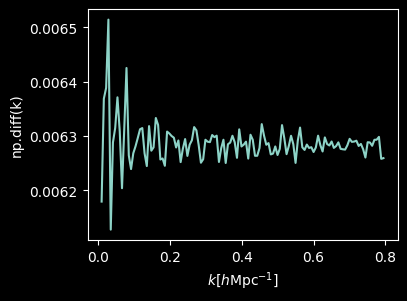

In [27]:
print(2*np.pi/1000) # delta_k
print(np.mean(np.diff(k)))
A = plt.figure(figsize = (4,3))
plt.plot(k[:-1], np.diff(k))
plt.xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 10)
plt.ylabel("np.diff(k)")

In [28]:
start = time.time()
down_factor = 2
k_down = k[::down_factor]

#dk_calc = np.mean(np.diff(k_down))
#k_edges = np.concatenate((k_down - 0.5*dk_calc,[k_down[-1] + 0.5*dk_calc]))
k_edges = k_down
bspec = pb.BSpec(base, 
                 k_edges, # k-bin edges
                 lmax=0
                )
end = time.time()
print("%.1f seconds of computation"%(end-start))


Binning: 63 bins in [0.009, 0.801] h/Mpc
l-max: 0
N_bins: 23344
Mask: constant
0.3 seconds of computation


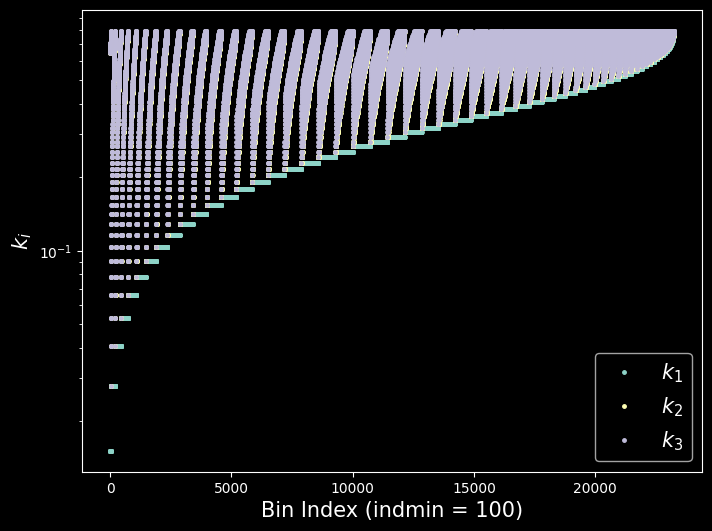

In [29]:
# Plot k-bins
indmin = 100
indmax = -1
k123 = bspec.get_ks()[:,indmin:indmax]
A = plt.figure(figsize = (8,6))
for i in range(3):
    plt.plot(k123[i],label=r'$k_%d$'%(i+1), ls = "None", marker = ".", markersize = 5)
plt.legend(fontsize=15);
plt.xlabel(r'Bin Index (indmin = %i)'%indmin,fontsize=15)
plt.ylabel(r'$k_i$',fontsize=15)
plt.xscale("linear")
plt.yscale("log")

In [30]:
bspec.Bk_ideal?

Signature:
bspec.Bk_ideal(
    data,
    fish_ideal=[],
    discreteness_correction=True,
    verb=False,
)
Docstring:
Compute the (normalized) idealized bispectrum estimator, weighting by 1/P_fid(k) within each bin. 

The estimator does *not* use the mask or S_inv weighting schemes (except for normalizing by < mask^3 >, and does not remove the linear term (which vanishes under ideal circumstances)

We optionally include 
discreteness corrections for ell>0.

This can compute the ideal bispectrum of simulation volumes, or, for suitably normalized input, the FKP power spectrum.
File:      ~/miniconda3/envs/pkcorr/lib/python3.10/site-packages/PolyBin3D/bspec.py
Type:      method

In [31]:
start = time.time()
bk_uncorr = bspec.Bk_ideal(delta_pm, discreteness_correction=False)
end = time.time()
print("%.1f seconds of computation"%(end-start))
# roughly 7-8 minutes of computation with a downsampling rate of 2

Computing degeneracy factor
Computing ideal Fisher matrix
343.7 seconds of computation


In [33]:
bk_uncorr.keys()

dict_keys(['b0'])

In [34]:
# Using k1 = k
ks = bspec.get_ks()
print(len(np.unique(ks[0,:])))

k1_vals = np.unique(ks[0,:])
n_bk = len(k1_vals)
print(k1_vals)

# inds = np.where(ks[0,:]==k1_vals[0])[0]
# print(inds.tolist())
# print(ks[:,inds].shape)
# print(ks[1:,inds].shape) 
# print(bk_uncorr["b0"][inds].shape)

63
[0.01517377 0.02789945 0.04055908 0.0531104  0.06570998 0.07833516
 0.09095594 0.10348277 0.11606231 0.12865852 0.14123172 0.15378956
 0.16639266 0.17897747 0.19151218 0.20409146 0.21668198 0.22924209
 0.2417999  0.25435954 0.26693788 0.27953948 0.29209081 0.30463645
 0.31722333 0.3298182  0.34238273 0.35491976 0.36747824 0.38005938
 0.39264022 0.40520905 0.41776586 0.43033796 0.44289965 0.45546344
 0.46805599 0.48062523 0.4931763  0.50572154 0.51830068 0.53088316
 0.54345021 0.55601427 0.56858296 0.58115995 0.59371832 0.60627208
 0.61883901 0.63141571 0.64398445 0.65655273 0.66912197 0.68168314
 0.6942384  0.70680972 0.71939264 0.73196709 0.74451895 0.75707562
 0.7696518  0.78223549 0.7947903 ]


In [35]:
# We are going to loop over k2=q and k3 that determines y = cos(theta)
start = time.time()
# Interpolator for gamma_q intervening in downsampled B term
interp_gamma = interp1d(k,gamma_k, kind = "linear")

# Bispectrum initialization
B_term = np.zeros(k1_vals.shape)

# This first loop is for the Bispec term over values of k1=k
i1=0
for k1 in k1_vals:
    inds = np.where(ks[0,:]==k1)[0]
    ks_k1 = ks[1:,inds]
    
    bk1 = bk_uncorr["b0"][inds]
    #print(bk1.shape)

    k2_vals =  ks_k1[0,:]
    k3_vals =  ks_k1[1,:]

    # For the integral over radial part, ie q modulus at fixed k (eq 59)
    B_integrand = np.zeros(k2_vals.shape)
    
    #k2=q values are all distinct, and so are k3 values for fixesd k1=k
    # This second loop is for fixed k
    i2 = 0
    for k2 in k2_vals:
        
        J_integrand = np.zeros(k3_vals.shape)
        y_arr  = np.zeros(k3_vals.shape)
        
        # We are computing J(k,q) in this loop, ie a sum over k3 (eq 58)
        i3=0
        for k3 in k3_vals:
            
            y = (k1**2 + k2**2 - k3**2)/(2*k1*k2)# cos(theta)
            J_integrand[i3] = y*bk1[i3]
            y_arr[i3] = y
            i3+=1

        J = np.trapz(J_integrand, y_arr )
        J *= 2*np.pi*k1/k2*interp_gamma(k2)
        B_integrand[i2] = k2**2 * J
        i2+=1

    B_term[i1] = np.trapz(B_integrand, k2_vals)
    i1+=1

# Do not forget the factor below, stemming from equation 53
B_term *= np.power(1./BoxSize,3)

end = time.time()
print("%.1f seconds of computation"%(end-start))

11.1 seconds of computation


In [36]:
print(B_term)

[-2.29406923e-02 -8.87740793e-03 -3.94081977e-03 -2.15508880e-03
 -1.20410764e-03 -7.53725418e-04 -5.35819381e-04 -3.25665267e-04
 -2.78127010e-04 -2.12140647e-04 -2.19312070e-04 -2.12059754e-04
 -1.37425054e-04 -1.14110987e-04 -1.32837819e-04 -1.33023759e-04
 -9.53912502e-05 -8.88500737e-05 -8.35104508e-05 -6.40300168e-05
 -6.52043965e-05 -5.80046746e-05 -4.30873381e-05 -4.42566751e-05
 -4.37647731e-05 -3.25135855e-05 -1.62215395e-05 -1.88237844e-05
 -1.38880823e-05 -9.86571486e-06 -3.73327419e-06 -9.16742584e-07
 -4.39322502e-06  3.72628082e-07 -1.88887994e-06 -1.20979888e-07
 -1.17513383e-06 -1.99177455e-06 -2.74358230e-06 -2.60877290e-06
 -2.43435060e-06 -3.76721444e-06 -3.63269187e-06 -3.31473584e-06
 -3.56217668e-06 -3.29102486e-06 -2.97718964e-06 -2.71654156e-06
 -2.43182741e-06 -2.16770421e-06 -1.83750563e-06 -1.58039633e-06
 -1.30899730e-06 -1.06779850e-06 -8.41139560e-07 -6.47565392e-07
 -4.64681230e-07 -3.24125178e-07 -2.14250248e-07 -1.16951478e-07
 -5.17348487e-08 -1.28153

Text(0.5, 0.98, 'Perfect correlation case, terms contribution')

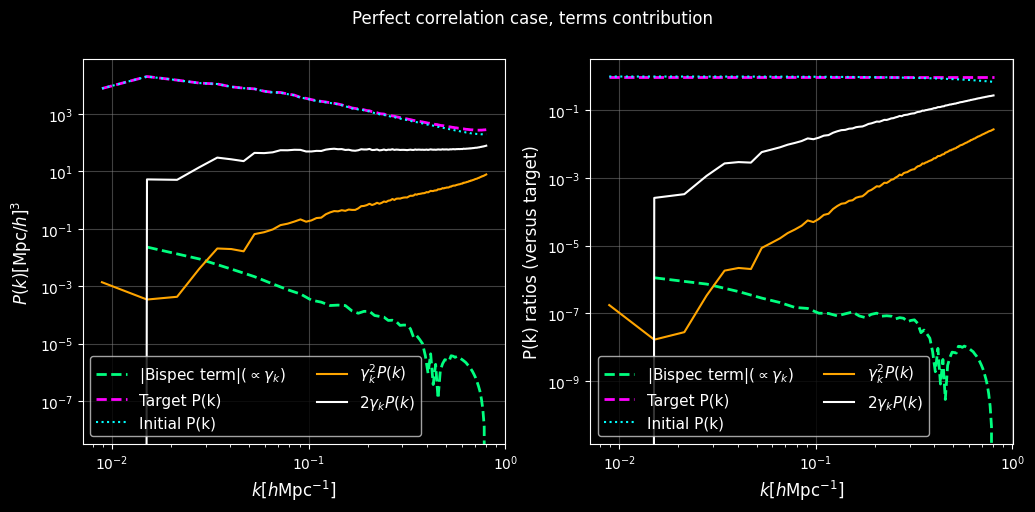

In [37]:
inds = np.where(k_nb <= kN)
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

ax1.plot(k1_vals, abs(B_term), color = "springgreen", ls = "--", lw = 2, label = "|Bispec term|" + r"($\propto \gamma_k$)")
ax1.plot(k, Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(k, Pk_pm[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(k, coeffs[:,0]*(roots[:,1].real)**2, color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax1.plot(k, coeffs[:,1]*roots[:,1].real, color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax1.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax1.set_ylabel(r"$P(k)[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.legend(fontsize = 11, ncols = 2)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

interp_pknb = interp1d(k, Pk_nb[inds])

ax2.plot(k1_vals, abs(B_term)/interp_pknb(k1_vals), color = "springgreen", ls = "--", lw = 2, label = "|Bispec term|"+ r"$(\propto \gamma_k)$")
ax2.plot(k, Pk_nb[inds]/Pk_nb[inds], color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(k, Pk_pm[inds]/Pk_nb[inds], color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax2.plot(k, coeffs[:,0]*(roots[:,1].real)**2/Pk_nb[inds], color = "orange", lw = 1.5, label = r"$\gamma_k^2P(k)$")
ax2.plot(k, coeffs[:,1]*roots[:,1].real/Pk_nb[inds], color = "white", lw = 1.5, label = r"$2\gamma_k P(k)$")
ax2.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
ax2.legend(fontsize = 11, ncols = 2)
ax2.set_xscale("log")
ax2.set_yscale("log")
ax2.grid(color = "grey", alpha = 0.5)

plt.suptitle("Perfect correlation case, terms contribution")

## 2-3) Root finding with Bispectrum contribution
Given previous test and computation times, it looks like a relevant idea to precompute the Bispectrum term with a downsampled k, to then pass the precomputed term as an interpolator on k to the solver.

In [36]:
def bispectrum_term(gamma_vec, k_vec, ks_b, bk_monopole):
    '''
    ks is an instance of get_ks()
    '''
    k1_vals = np.unique(ks_b[0,:])
    n_bk = len(k1_vals)

    # Interpolator for gamma_q intervening in downsampled B term
    interp_gamma = interp1d(k_vec, gamma_vec, kind = "linear")

    # Bispectrum initialization
    B_term = np.zeros(k1_vals.shape)
    
    # This first loop is for the Bispec term over values of k1=k
    i1=0
    for k1 in k1_vals:
        inds = np.where(ks[0,:]==k1)[0]
        ks_k1 = ks[1:,inds]
        
        bk1 = bk_monopole[inds]
        #print(bk1.shape)
    
        k2_vals =  ks_k1[0,:]
        k3_vals =  ks_k1[1,:]
    
        # For the integral over radial part, ie q modulus at fixed k (eq 59)
        B_integrand = np.zeros(k2_vals.shape)
        
        #k2=q values are all distinct, and so are k3 values for fixesd k1=k
        # This second loop is for fixed k
        i2 = 0
        for k2 in k2_vals:
            
            J_integrand = np.zeros(k3_vals.shape)
            y_arr  = np.zeros(k3_vals.shape)
            
            # We are computing J(k,q) in this loop, ie a sum over k3 (eq 58)
            i3=0
            for k3 in k3_vals:
                
                y = (k1**2 + k2**2 - k3**2)/(2*k1*k2)# cos(theta)
                J_integrand[i3] = y*bk1[i3]
                y_arr[i3] = y
                i3+=1
    
            J = np.trapz(J_integrand, y_arr )
            J *= 2*np.pi*k1/k2*interp_gamma(k2)
            B_integrand[i2] = k2**2 * J
            i2+=1
    
        B_term[i1] = np.trapz(B_integrand, k2_vals)
        i1+=1
    
    # Do not forget the factor below, stemming from equation 53
    B_term *= np.power(1./BoxSize,3)

    return B_term
    

In [37]:
def correlated_case_system(gamma_vec, k_vec, Pk_target, Pk, kbis, bk_mono):
    
    bispec_term = bispectrum_term(gamma_vec, k_vec, kbis, bk_mono)
    k_vals = np.unique(kbis[0,:])
    interp_bkterm = interp1d(k_vals, bispec_term, fill_value="extrapolate")
    
    sum_system = Pk - Pk_target +  gamma_vec**2 * Pk  + 2*gamma_vec * Pk + interp_bkterm(k_vec)
    return sum_system

scipy.optimize.show_options(solver = "root")



hybr
====

Find the roots of a multivariate function using MINPACK's hybrd and
hybrj routines (modified Powell method).

Options
-------
col_deriv : bool
    Specify whether the Jacobian function computes derivatives down
    the columns (faster, because there is no transpose operation).
xtol : float
    The calculation will terminate if the relative error between two
    consecutive iterates is at most `xtol`.
maxfev : int
    The maximum number of calls to the function. If zero, then
    ``100*(N+1)`` is the maximum where N is the number of elements
    in `x0`.
band : tuple
    If set to a two-sequence containing the number of sub- and
    super-diagonals within the band of the Jacobi matrix, the
    Jacobi matrix is considered banded (only for ``fprime=None``).
eps : float
    A suitable step length for the forward-difference
    approximation of the Jacobian (for ``fprime=None``). If
    `eps` is less than the machine precision, it is assumed
    that the relative errors in the 

In [46]:
inds = np.where(k_nb <= kN)
k = k_nb[inds]

def my_call(xx,ff):
    print("Current x is ", xx)
    
# my_method = "hybr"
# opt_dict = opt_dict = {"maxfev":5, "return_all":True}

# my_method = "lm"
# opt_dict = {"maxiter":5, "return_all":True}

my_method = "krylov"
opt_dict = {"nit":10, "return_all":True}

solution = scipy.optimize.root(correlated_case_system,x0 = gamma_k, 
                                args =(k, Pk_nb[inds], Pk_pm[inds], ks, bk_uncorr["b0"]), callback=my_call,
                               method = my_method, options=opt_dict)

/tmp/ipykernel_930583/714429282.py:16: OptimizeWarning: Unknown solver options: return_all
  solution = scipy.optimize.root(correlated_case_system,x0 = gamma_k,


Current x is  [-4.17672975e-04  1.29953666e-04  1.67539074e-04  5.81307820e-04
  1.35709689e-03  1.48585006e-03  1.43294423e-03  2.94106230e-03
  3.49434028e-03  4.08623828e-03  4.88808608e-03  5.51887583e-03
  6.28251311e-03  7.52495477e-03  7.12099742e-03  7.90311324e-03
  9.09906472e-03  9.47536981e-03  1.11544549e-02  1.23763243e-02
  1.33758626e-02  1.36376445e-02  1.47822278e-02  1.50785154e-02
  1.64400603e-02  1.69965800e-02  1.73184971e-02  1.88040621e-02
  2.06997762e-02  2.15388525e-02  2.29679381e-02  2.45080201e-02
  2.42071887e-02  2.58244746e-02  2.76816068e-02  2.75230453e-02
  2.89478222e-02  3.07457760e-02  3.13338079e-02  3.31497715e-02
  3.45343620e-02  3.67989713e-02  3.60264926e-02  3.87756301e-02
  3.97196291e-02  4.02627748e-02  4.19560727e-02  4.33153129e-02
  4.42199503e-02  4.46624608e-02  4.73768263e-02  4.94562282e-02
  5.01495628e-02  5.17194272e-02  5.48152988e-02  5.43502097e-02
  5.65588323e-02  5.73952547e-02  5.91780948e-02  6.05214899e-02
  6.1569634

In [42]:
# Save or load root finding solution
#np.save("krylov_10it.npy", solution["x"])
solution = {"x":np.load("krylov_10it.npy")}
solution["x"].shape

(127,)

In [43]:
solution["x"]/roots_nb[:,1].real

array([0.99545249, 1.0043468 , 1.00312345, 1.00063647, 1.00020835,
       1.00014917, 1.00013282, 1.00004832, 1.0000382 , 1.00002568,
       1.00001769, 1.00001368, 1.00001119, 1.00000937, 1.00000858,
       1.00000647, 1.00000572, 1.00000531, 1.00000419, 1.00000345,
       1.00000342, 1.00000362, 1.00000352, 1.00000371, 1.000003  ,
       1.00000251, 1.00000233, 1.00000204, 1.00000203, 1.00000222,
       1.00000222, 1.00000212, 1.00000199, 1.00000165, 1.00000153,
       1.00000159, 1.0000015 , 1.00000139, 1.00000129, 1.00000107,
       1.00000109, 1.00000105, 1.00000105, 1.00000096, 1.00000084,
       1.00000074, 1.00000074, 1.00000075, 1.00000075, 1.00000075,
       1.00000064, 1.00000054, 1.00000041, 1.00000027, 1.00000028,
       1.00000031, 1.00000027, 1.00000023, 1.0000002 , 1.00000016,
       1.00000011, 1.00000006, 1.00000004, 1.00000002, 1.00000004,
       1.00000007, 1.00000003, 0.99999999, 1.00000001, 1.00000003,
       1.00000002, 1.        , 1.00000001, 1.00000002, 1.00000

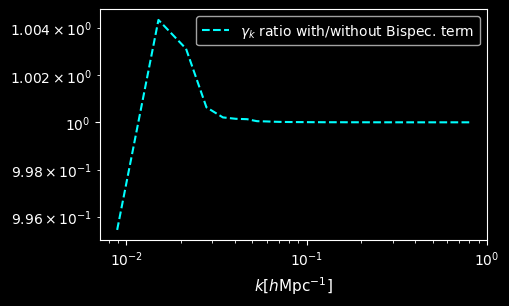

In [44]:
fig = plt.figure(figsize = (5,3))
#plt.plot(k, roots_nb[:,1].real/k**2, label = "Without Bk Term", ls = "--", zorder =3, color = "red")
plt.plot(k, solution["x"]/roots_nb[:,1].real, label = r"$\gamma_k$" + " ratio with/without Bispec. term", ls = "--", zorder =3, color = "cyan")
plt.legend(fontsize = 12)
plt.xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize = 11)
#plt.ylabel(r"$\gamma_k/k^2$", fontsize = 11)
plt.loglog()
plt.legend()

In [45]:
freq = np.fft.fftshift(np.fft.fftfreq(grid)) # second argument is sample spacing, inverse of sampling rate 1/L_s
fx, fy, fz = np.meshgrid(freq, freq, freq, indexing='ij')

scale = 2*np.pi*grid/BoxSize # k sampling rate

# Compute MAS correction factors
MAS_factor_kx = MAS_correction(scale* fx* np.pi/2.*1./kN, MAS_index)
MAS_factor_ky = MAS_correction(scale* fy* np.pi/2.*1./kN, MAS_index)
MAS_factor_kz = MAS_correction(scale * fz* np.pi/2.*1./kN , MAS_index)
MAS_factor = MAS_factor_kx * MAS_factor_ky * MAS_factor_kz

# MY COMPUTATION
prec_dict = {"float32":"complex64", "float64": "complex128", "complex64":"complex64"}
prec_in ="complex64"
prec_out = prec_dict[prec_in]
N_CPU = 16

a_in  = pyfftw.empty_aligned((grid,grid,grid),  dtype=prec_in)
a_out = pyfftw.empty_aligned((grid,grid,grid),dtype='complex64')
# plan FFTW
fftw_plan = pyfftw.FFTW(a_in, a_out, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_FORWARD', threads=N_CPU)
# put input array into delta_r and perform FFTW
a_in[:] = delta_pm.astype(prec_in)
delta_pm_fourier = fftw_plan(a_in,a_out)

delta_pm_fourier_shift = np.fft.fftshift(delta_pm_fourier, axes=(0,1,2))

# Careful about mutliplication or division depending on "MAS factor" definition
delta_k = delta_pm_fourier_shift*MAS_factor

# Compute radial distances
rad = np.sqrt(fx**2 + fy**2 + fz**2)*scale
print(rad.min(), rad.max())

fshift = True
kx_v, ky_v, kz_v, k_radius = fourier_shells_k(grid, BoxSize, fshift = fshift)
print(np.isclose(rad,k_radius).all())

weights1D = solution["x"]#roots[:,1].real/(k**2)
# Put gamma_k weights in 3D
weights_grid = np.empty(delta_k.shape)
weights_grid = fill_fourier_grid(weights_grid, k_radius , k, weights1D)

# Finally compute Phi_k
phi_k = weights_grid * delta_k

# MY RECIPE
freq = np.array(np.fft.fftshift(np.fft.fftfreq(grid))*scale, dtype = "float32")
grad_x_fourier_alt = 1.0j*freq[:,np.newaxis, np.newaxis] * phi_k
grad_y_fourier_alt = 1.0j*freq[np.newaxis,:, np.newaxis] * phi_k
grad_z_fourier_alt = 1.0j*freq[np.newaxis, np.newaxis, :] * phi_k

arr_inx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_iny  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_inz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_out)
arr_outx  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outy  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)
arr_outz  =  pyfftw.empty_aligned((grid, grid, grid), dtype=prec_in)

fftw_planx = pyfftw.FFTW(arr_inx, arr_outx, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_plany = pyfftw.FFTW(arr_iny, arr_outy, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)
fftw_planz = pyfftw.FFTW(arr_inz, arr_outz, axes=(0,1,2),
                        flags=('FFTW_ESTIMATE',),
                        direction='FFTW_BACKWARD', threads=N_CPU)

# Fill data in advance with builders interface
arr_inx[:] =  grad_x_fourier_alt.astype(prec_out)
arr_iny[:] =  grad_y_fourier_alt.astype(prec_out)
arr_inz[:] =  grad_z_fourier_alt.astype(prec_out)

a_x_sol = fftw_planx(np.fft.ifftshift(arr_inx), arr_outx).real
a_y_sol = fftw_plany(np.fft.ifftshift(arr_iny), arr_outy).real
a_z_sol = fftw_planz(np.fft.ifftshift(arr_inz), arr_outz).real

cell = BoxSize/grid # one grid cell in :pc/h
length_grid = np.arange(start = 0. , stop = BoxSize, step = cell)
comoving_length = length_grid + cell/2
arr_interp = length_grid

0.0 1.3929979117318794
True


In [46]:
# MINE: TRILINEAR INTERPOLATION
prec_in = "float32"
pos_corrected_sol= np.empty(pos_pm.shape).astype(prec_in)

pos_corrected_alt, nabla_x_i, nabla_y_i, nabla_z_i= displace_positions_interp(pos_pm, pos_corrected_sol, a_x_sol.astype("float32"), a_y_sol.astype("float32"), a_z_sol.astype("float32"),
                                            arr_interp, arr_interp, arr_interp, BoxSize, threshold=BoxSize/grid)

delta_corrected_sol=get_delta(pos=pos_corrected_sol, grid=grid, W=0, mass=1, BoxSize=BoxSize, MAS=MAS, verbose=True)
k_corrected_sol, Pk_disp_sol, _, _ = compute_Pk(delta_corrected_sol, BoxSize=BoxSize, MAS=MAS, axis=0, verbose=True)


0.256 0.256 0.256
0.256 0.256 0.256
0.256 0.256 0.256

Using CIC mass assignment scheme
Time taken = 1.811 seconds


Computing power spectrum of the field...
Time to complete loop = 0.54
Time taken = 0.82 seconds


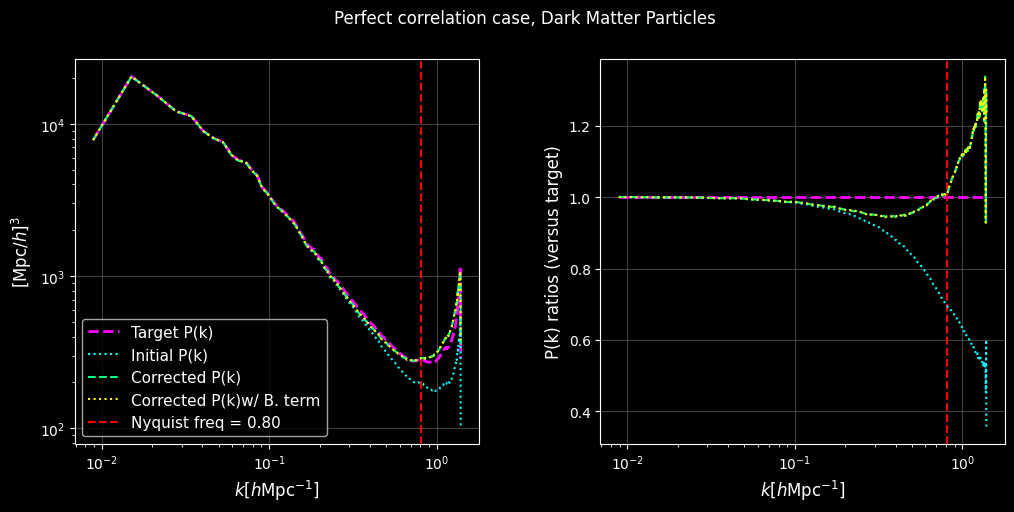

In [49]:
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False)
ax1 = axes[0]
ax2 = axes[1]

# temporary fix
kplot = k_corrected_alt.copy()

ax1.plot(kplot, Pk_target, color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax1.plot(kplot, Pk_pm, color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax1.plot(kplot, Pk_disp_alt, color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax1.plot(kplot, Pk_disp_sol, color = "yellow", lw = 1.5, label = "Corrected P(k)w/ B. term", ls = "dotted", zorder = 5)
ax1.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax1.set_ylabel(r"$[\mathrm{Mpc}/h]^3$", fontsize =12)
ax1.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kN)
ax1.legend(fontsize = 11)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.grid(color = "grey", alpha = 0.5)

ax2.plot(kplot, Pk_target/Pk_target, color = "magenta", ls = "--", lw = 2, label = "Target P(k)")
ax2.plot(kplot, Pk_pm/Pk_target, color = "cyan", lw = 1.5, label = "Initial P(k)", ls = "dotted", zorder = 5)
ax2.plot(kplot, Pk_disp_alt/Pk_target, color = "springgreen", lw = 1.5, label = "Corrected P(k)", ls = "dashed", zorder = 5)
ax2.plot(kplot, Pk_disp_sol/Pk_target, color = "yellow", lw = 1.5, label = "Corrected P(k) w/ B. term", ls = "dotted", zorder = 5)
ax2.set_xlabel(r"$k [h\text{Mpc}^{-1}]$", fontsize =12)
ax2.set_ylabel(r"P(k) ratios (versus target)", fontsize =12)
#ax2.legend(fontsize = 11)
ax2.set_xscale("log")
ax2.set_yscale("linear")
ax2.grid(color = "grey", alpha = 0.5)
plt.subplots_adjust(wspace = 0.3)
plt.suptitle("Perfect correlation case, Dark Matter Particles")
ax2.axvline(np.pi*grid/BoxSize,  color='r',ls='--', label='Nyquist freq = %.2f'%kN)

# 3) Dark Matter Particles - uncorrelated case

We assume a perturbation field so that
\begin{align}
\langle \phi_{\mathbf{q}} \phi_{\mathbf{q}'}^* \rangle = (2\pi)^3 \delta(\mathbf{q} - \mathbf{q}') Q(q)
\end{align}
so that the equation for the density contrast of the perturbed particles becomes, averaged over the perturbation field,

\begin{align}
\langle |\Delta'_{\mathbf{k}}|^2\rangle_{\phi} &\approx |\Delta_{\mathbf{k}}^2| + k^4 (2\pi)^3 Q(k) +\frac{(2\pi)^3}{V^2}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q)|\Delta_{\mathbf{k-q}}|^2 \\
&+ 2 \operatorname{Re}\left[ k^2\Delta_{\mathbf{k}}\mathbb{E}_{\phi}[\phi_{\mathbf{k}}^{\ast}] +\frac{(2\pi)^3k^4}{V} Q(k)\Delta_{\mathbf{k-q=0}}^{\ast} \right. \nonumber \\
 &+\left. \frac{1}{V}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q}) 
\mathbb{E}_{\phi}[\phi_{\mathbf{q}}^{\ast}]\Delta_{\mathbf{k}}\Delta_{\mathbf{k-q}}^{\ast}
 \right. \nonumber \\
 & - \left. \frac{(2\pi)^3}{2V^2} \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q) \Delta_{\mathbf{k}}\Delta^{\ast}_{\mathbf{k}}\right]\,.
\end{align}

In the very last line, we used $\phi_{\mathbf{q}}^{\ast} =\phi_{-\mathbf{q}} $ to make $Q$ appear when taking the expectation, hence the minus sign.
Finally, when averaged over $\Delta$, we obtain

\begin{align}
    \langle \langle |\Delta'_{\mathbf{k}}|^2\rangle_{\phi} \rangle_{\Delta}&\approx P(k) + k^4  Q(k)
    +\frac{(2\pi)^3}{V^2}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q)P(|\mathbf{k}-\mathbf{q}|) \nonumber \\
    &- \frac{(2\pi)^3}{2V^2} \sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q) P(k)
\end{align}


To compute the angular integral of $(\mathbf{k} \cdot \mathbf{q})^2 Q(q) P(|\mathbf{k}-\mathbf{q}|)$ we'll keep $|\mathbf{k}| = k$ fixed, while the modulus $q$ can vary.
 There is only one angular integral over $\Omega_\mathbf{q}$, since the sum is over $\mathbf{q}$, and not over $\Omega_\mathbf{k}$.
 
Rewrite the dot product $(\mathbf{k} \cdot \mathbf{q})^2$ in terms of the cosine of the angle between $\mathbf{k}$ and $\mathbf{q}$:

   $$(\mathbf{k} \cdot \mathbf{q})^2 = k^2 q^2 \cos^2 \theta,$$
where $\theta$ is the angle between $\mathbf{k}$ and $\mathbf{q}$.

Express the integral in spherical coordinates
$$I(k, q) = \int d\Omega_\mathbf{q} \, k^2 q^2 \cos^2 \theta \, Q(q) P(|\mathbf{k}-\mathbf{q}|).$$

The magnitude of the difference vector $|\mathbf{k}-\mathbf{q}|$ can be expressed in terms of $k$, $q$, and $\theta$ using the cosine law
$$|\mathbf{k}-\mathbf{q}|^2 = k^2 + q^2 - 2kq \cos \theta.$$

Expand the integral in spherical coordinates

$$I(k, q) = \int_0^{2\pi} d\phi_q \int_0^{\pi} d\theta_q \sin \theta_q \, k^2 q^2 \cos^2 \theta \, Q(q) P(\sqrt{k^2 + q^2 - 2kq \cos \theta}).$$

The integral $\phi_q$  gives a factor of $2\pi$.  The integrand only depends on the angle between $\mathbf{k}$ and $\mathbf{q}$. Therefore, the integration over $\hat{\mathbf{q}}$ will give the same result for any fixed $\hat{\mathbf{k}}$. To evaluate the integration over $\hat{\mathbf{q}}$ we can choose $\hat{\mathbf{k}}$ along  
$\hat{\mathbf{z}}$, since the value of the integral does not depend on that choice. Then the integral over $\theta_q$ can be performed using the substitution $\cos \theta = \hat{\mathbf{k}} \cdot \hat{\mathbf{q}}$
$$I(k, q) = k^2 q^2 Q(q) \int_0^{2\pi} d\phi_k \int_{-1}^{1} d(\cos \theta) \cos^2 \theta \, P(\sqrt{k^2 + q^2 - 2kq \cos \theta}).$$

$$I(k, q) = 2\pi k^2 q^2 Q(q) \int_{-1}^{1} d(\cos \theta) \cos^2 \theta \, P(\sqrt{k^2 + q^2 - 2kq \cos \theta}).$$

The final result is
$$I(k, q) = 2\pi k^2 q^2 Q(q) \int_{-1}^{1}\, P(\sqrt{k^2 + q^2 - 2kq z}) z^2 dz $$

This expression can be evaluated numerically for given power spectra $Q(q)$ and $P(k)$. 

Finally, 

\begin{equation}
    J_1(k) \equiv \frac{(2\pi)^3}{V^2}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q)P(|\mathbf{k}-\mathbf{q}|) = \frac{(2\pi)^3}{V^2}I(k,q)\,.
\end{equation}

The additional term, when using $\Phi$ up to second order in the perturbed field density contrast, can be computed similarly with $P(|\mathbf{k}-\mathbf{q}|)$ replaced by $P(k)$ in the previous equations, which can be put out of the integral that simply becomes $\int_{-1}^{1}z^2dz = -\frac{2}{3}.$


\begin{equation}
    J_2(k) \equiv \frac{(2\pi)^3}{2V^2}\sum_{\mathbf{q}} (\mathbf{k} \cdot \mathbf{q})^2 Q(q)P(k) = -\frac{2}{3}\frac{(2\pi)^3}{2V^2}q^{2}2\pi k^2 P(k) Q(q)\,.
\end{equation}

## 3-1) Q computations
We look at both first and second order systems (in $\Phi$)

In [38]:
def calculate_I_terms(k, Pk0, BoxSize, dz = 1e-3):
    
    I1=np.zeros([len(k), len(k)])
    I2=np.zeros([len(k), len(k)])
    J1=np.zeros((len(k),))
    J2=np.zeros((len(k),))
    z=np.arange(-1,1+dz,dz)
    
    for i,ki in enumerate(k):
        for j,qj in enumerate(k):
            k_in=np.sqrt(ki**2+qj**2-2*ki*qj*z)
            Pk_nl=np.interp(k_in, k, Pk0)
            if ki==qj:
                Pk_nl[-1]=0

            I1[i,j]=2*np.pi*ki**2*qj**2*np.trapz(Pk_nl*z**2,z)
            I2[i,j]=2*np.pi*ki**2*qj**2*(2./3.)*Pk0[i]

    I1*= np.power(2*np.pi/BoxSize**2,3)
    I2*= 0.5*np.power(2*np.pi/BoxSize**2,3)

    return I1, I2

def Q_solver(Qk, k, Pk0, Pk0_target, BoxSize, dz = 1e-3):

    I1, I2 = calculate_I_terms(k, Pk0, BoxSize, dz = 1e-3)
    system = Pk0 - Pk0_target + k**4 * Qk
    system += np.trapz(k**2*Qk*I1,k) + np.trapz(k**2*Qk*I2) # += J1 + J2

    return system

# def Q_solver(k, Pk0, Pk0_target, BoxSize, dz = 1e-3):

#     I1, I2 = calculate_J_terms(k, Pk0, BoxSize, dz = 1e-3)

#     J3=np.identity(len(k))
#     for i, ki in enumerate(k):
#         J3[i,i]*=ki**4

#     system1 =  J1
#     system2 =  J1 - J2

#     B = -1.* (Pk0_target-Pk0) # putting on left side of equationPk0 - Pk0_target

#     Qk1=np.matmul(np.linalg.inv(system1),B)
#     Qk2=np.matmul(np.linalg.inv(system2),B)

#     return Qk1,Qk2, J1, J2
    

In [39]:
inds = np.where(k_nb <= kN)
k = k_nb[inds]
Q_first, Q_second, J1, J2 = Q_solver(k, Pk_pm[inds], Pk_nb[inds], BoxSize, dz = 1e-3)

/tmp/ipykernel_2929551/1188581951.py:11: RuntimeWarning: invalid value encountered in sqrt
  k_in=np.sqrt(ki**2+qj**2-2*ki*qj*z)


LinAlgError: 1-dimensional array given. Array must be at least two-dimensional

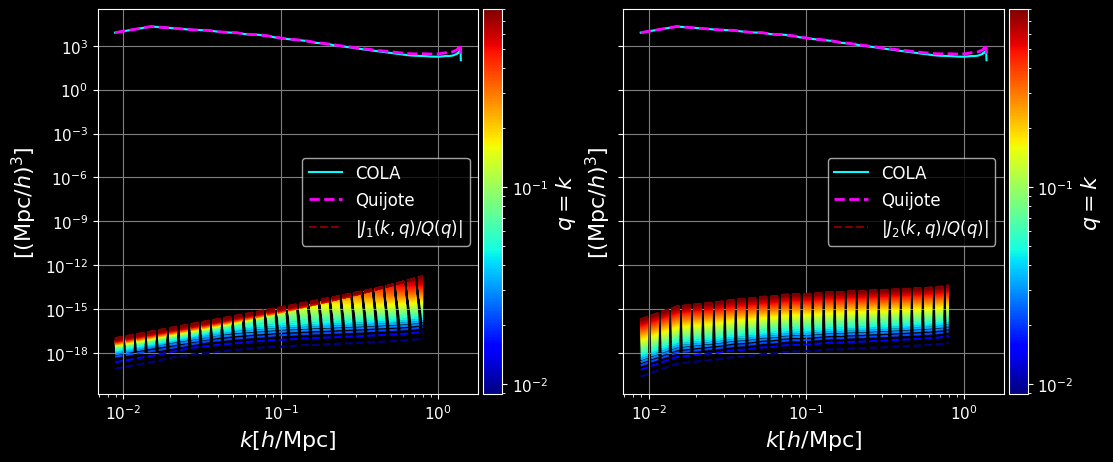

In [99]:
#colorsc = plt.cm.jet(np.linspace(0,1,(len(k))))
from matplotlib import colors, cm
from mpl_toolkits.axes_grid1.axes_divider import make_axes_locatable

cmap1 = cm.jet
norm1 = colors.LogNorm(vmin=k.min(), vmax=k.max())
print(norm)
fig, axes = plt.subplots(figsize = (12,5), ncols = 2, nrows = 1, sharex = False, sharey = True)
ax1 = axes[0]; ax2 = axes[1]
ax1.plot(k_pm, Pk_pm, label="COLA", zorder = 3, color = "cyan")
ax1.plot(k_nb, Pk_nb,"--", label='Quijote', lw = 2, color = "magenta", zorder = 4)
ax2.plot(k_pm, Pk_pm, label="COLA", zorder = 3, color = "cyan")
ax2.plot(k_nb, Pk_nb,"--", label='Quijote', lw = 2, color = "magenta", zorder = 4)
for n in range(len(k)):
    l1 = r"$|J_1(k,q)/Q(q)|$" if n==len(k)-1 else None
    l2 = r"$|J_2(k,q)/Q(q)|$" if n==len(k)-1 else None
    ax1.plot(k, abs(J1[:,n]), color = cmap1(norm1(k[n])), ls = "--", zorder = 5, label = l1)
    ax2.plot(k, abs(J2)[:,n], color = cmap1(norm1(k[n])), ls = "--", zorder = 5, label = l2)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax1.tick_params(labelsize = 11)
#fig.colorbar(colors ,ax=ax1, label="dy/dx")

ax2.legend(fontsize = 12)
ax2.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax2.set_yscale("log")
ax2.set_xscale("log")
ax2.set_ylabel(r"$[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax2.grid(color = "grey")
ax2.tick_params(labelsize = 11)

divider = make_axes_locatable(ax1)
cax = divider.append_axes('right', size='5%', pad=0.05)
sm = plt.cm.ScalarMappable(norm=norm1, cmap=cmap1)

cbar = fig.colorbar(sm,cax =cax)
cbar.set_label(r"$q=k$", fontsize = 16)
cbar.ax.tick_params(labelsize=11)

divider = make_axes_locatable(ax2)
cax = divider.append_axes('right', size='5%', pad=0.05)
sm = plt.cm.ScalarMappable(norm=norm1, cmap=cmap1)

cbar = fig.colorbar(sm,cax =cax)
cbar.set_label(r"$q=k$", fontsize = 16)
cbar.ax.tick_params(labelsize=11)
plt.subplots_adjust(wspace = 0.3)

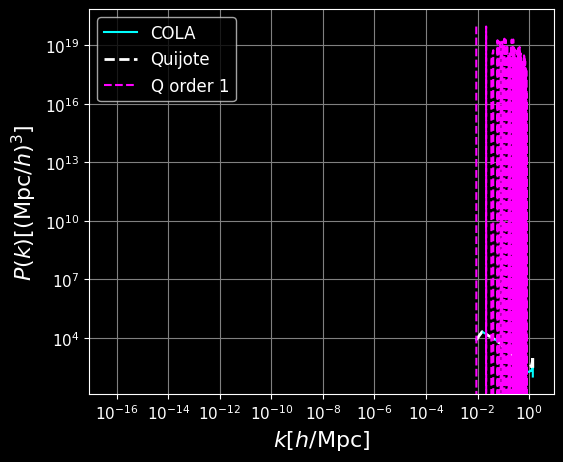

In [56]:
fig, ax1 = plt.subplots(figsize = (6,5), ncols = 1, nrows = 1, sharex = False)
ax1.plot(k_pm, Pk_pm, label="COLA", zorder = 3, color = "cyan")
ax1.plot(k_nb, Pk_nb,"--", label='Quijote', lw = 2, color = "white", zorder = 4)
ax1.plot(k, Q_first, label='Q order 1', color = "magenta", ls = "--", zorder = 5)
#ax1.plot(k, Q_second, label='Q order 2', color = "yellow", ls = "--", zorder = 5)
ax1.legend(fontsize = 12)
ax1.axvline()
ax1.grid(color = "grey")
ax1.set_ylabel(r"$P(k)[(\mathrm{Mpc}/h)^3]$", fontsize = 16)
ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlabel(r"$k [h/\mathrm{Mpc}]$", fontsize = 16)
ax1.tick_params(labelsize = 11)

In [48]:

def get_phi(k, Qk, grid=128, BoxSize=1000.0, Rayleigh_sampling=1, seed=1, threads=1, verbose=True):
    
    # seed              = 1      #value of the initial random seed
    # Rayleigh_sampling = 1      #whether sampling the Rayleigh distribution for modes amplitudes
    # threads           = 1      #number of openmp threads
    # verbose           = True   #whether to print some information

    k, Qk = k.astype(np.float32), Qk.astype(np.float32)

    # generate a 3D Gaussian density field
    phi = DFL.gaussian_field_3D(grid, k, Qk, Rayleigh_sampling, seed,
                                  BoxSize, threads, verbose)

    return phi